# Load libraries

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn seaborn umap-learn scipy shap PyALE


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip3 install --upgrade pip


In [7]:
import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps  # Ensure this is imported
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns
import math
import json
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.svm import SVR
from sklearn.metrics import root_mean_squared_error, r2_score
import shap
from PyALE import ale
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import linregress, spearmanr
from sklearn.preprocessing import StandardScaler

# Loading the data

In [27]:
chamau_lag = pd.read_csv("../datasets/Chamau_2014-2024_clean_newlag.csv")
chamau_daily = pd.read_csv("../datasets/Chamau_Daily_2014-2024_newlag.csv")
oensingen_1_lag = pd.read_csv("../datasets/Oensingen_2018-19_clean_newlag.csv")
oensingen_1_daily = pd.read_csv("../datasets/Oensingen_Daily_2018-19_clean_newlag.csv")
oensingen_2_lag = pd.read_csv("../datasets/Oensingen_2021-23_clean_newlag.csv")
oensingen_2_daily = pd.read_csv("../datasets/Oensingen_Daily_2021-23_clean_newlag.csv")
aeschi_lag = pd.read_csv("../datasets/Aeschi_2019-20_clean_newlag.csv")
aeschi_daily = pd.read_csv("../datasets/Aeschi_Daily_2019-20_newlag.csv")
forel_lag = pd.read_csv("../datasets/Forel_2024-25_clean_newlag.csv")
forel_daily = pd.read_csv("../datasets/Forel_Daily_2024-25_clean_newlag.csv")
tanikon_lag = pd.read_csv("../datasets/Tanikon_2023-25_clean_newlag.csv")
tanikon_daily = pd.read_csv("../datasets/Tanikon_Daily_2023-25_clean_newlag.csv")

# Model setup

In [30]:
def train_svr_timeseries(df, predictors, target, test_size=0.1, kernel='rbf', C=1.0, epsilon=0.1, plot=True):
    """
    Train SVR on time-series data using chronological split.
    
    Now includes a time series comparison plot showing observed vs predicted values over time.
    """
    
    # EXTRACT FEATURES/TARGET
    X = df[predictors]
    y = df[target]
    
    # HANDLE NaNs
    mask = X.notna().all(axis=1) & y.notna()
    X, y = X[mask], y[mask]
    
    # OFFSET FOR POSITIVITY (same as XGBoost)
    offset = abs(y.min()) + 1e-6
    y_shifted = y + offset
    
    # CHRONOLOGICAL SPLIT
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y_shifted.iloc[:split_idx], y_shifted.iloc[split_idx:]
    
    # Store test dates for time series plot
    test_dates = X_test.index
    
    time_train = (df.index.min(), df.index[:split_idx].max())
    time_test = (df.index[split_idx], df.index.max())
    
    print(f"Train period: {time_train[0]} → {time_train[1]}")
    print(f"Test  period: {time_test[0]} → {time_test[1]}")
    
    # ========== DATA LEAKAGE CHECK ==========
    try:
        # For hourly data with Timestamp index
        train_dates_set = set(X_train.index.date)
        test_dates_set = set(X_test.index.date)
    except AttributeError:
        # For daily data where index is integer, get dates from original df
        train_indices = X_train.index
        test_indices = X_test.index
        
        if 'Date' in df.columns:
            train_dates_set = set(pd.to_datetime(df.loc[train_indices, 'Date']).dt.date)
            test_dates_set = set(pd.to_datetime(df.loc[test_indices, 'Date']).dt.date)
        else:
            train_dates_set = set()
            test_dates_set = set()
            print("  ⚠️  Cannot check for data leakage (no Date column found)")
    
    overlap_dates = train_dates_set & test_dates_set
    if len(overlap_dates) > 0:
        print(f"  ⚠️  DATA LEAKAGE WARNING: {len(overlap_dates)} dates appear in BOTH train and test!")
    else:
        print(f"  ✅ No data leakage detected")
    # =========================================
    
    # SCALE FEATURES (critical for SVR)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # TRAIN MODEL
    print(f"\nTraining SVR with kernel={kernel}, C={C}, epsilon={epsilon}...")
    model = SVR(
        kernel=kernel,
        C=C,
        epsilon=epsilon,
        gamma='scale'
    )
    model.fit(X_train_scaled, y_train)
    
    # PREDICTIONS
    y_pred = model.predict(X_test_scaled)
    
    # EVALUATION
    r2 = r2_score(y_test, y_pred)
    rho, _ = spearmanr(y_test, y_pred)
    
    print("\nModel evaluation:")
    print(f"  R² (linear scale): {r2:.3f}")
    print(f"  Spearman ρ:        {rho:.3f}")
    
    # PLOT
    if plot:
        # Create 2-subplot figure: scatter and TIME SERIES
        # (SVR doesn't have built-in feature importance like XGBoost)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # 1. Scatter plot
        axes[0].scatter(y_test, y_pred, alpha=0.6, s=20)
        min_val, max_val = y_test.min(), y_test.max()
        axes[0].plot([min_val, max_val], [min_val, max_val], "r--", lw=2)
        axes[0].set_xlabel("Observed N₂O Flux")
        axes[0].set_ylabel("Predicted N₂O Flux")
        axes[0].set_title(f"SVR {kernel.upper()} (R²={r2:.3f}, ρ={rho:.3f})")
        axes[0].grid(True, alpha=0.3)
        
        # 2. TIME SERIES COMPARISON
        axes[1].plot(test_dates, y_test.values, label="Observed", color="black", lw=1.5)
        axes[1].plot(test_dates, y_pred, label="Predicted", color="royalblue", lw=1.5, alpha=0.8)
        axes[1].set_xlabel("Date")
        axes[1].set_ylabel("N₂O Flux")
        axes[1].set_title("Time Series Comparison")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        # Rotate x-axis labels for better readability
        plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        plt.tight_layout()
        plt.show()
    
    return {
        "model": model,
        "scaler": scaler,
        "r2": r2,
        "spearman_rho": rho,
        "y_test": y_test,
        "y_pred": y_pred,
        "test_dates": test_dates,
    }

# Experiment 1: Chamau

In [5]:
# FIX TIMESTAMP
chamau_lag['Timestamp'] = pd.to_datetime(chamau_lag['Timestamp'])
chamau_lag = chamau_lag.set_index('Timestamp').sort_index()

chamau_daily['Date'] = pd.to_datetime(chamau_daily['Date'])
chamau_daily = chamau_daily.set_index('Date').sort_index()

EXPERIMENT 4: Chamau 2014-2024

--- HOURLY | target=N2O_Flux_ln | predictors=BASE ---
Train period: 2014-01-01 08:15:00 → 2021-07-31 12:15:00
Test  period: 2021-07-31 13:15:00 → 2022-07-06 09:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...



Model evaluation:
  R² (linear scale): 0.120
  Spearman ρ:        0.337


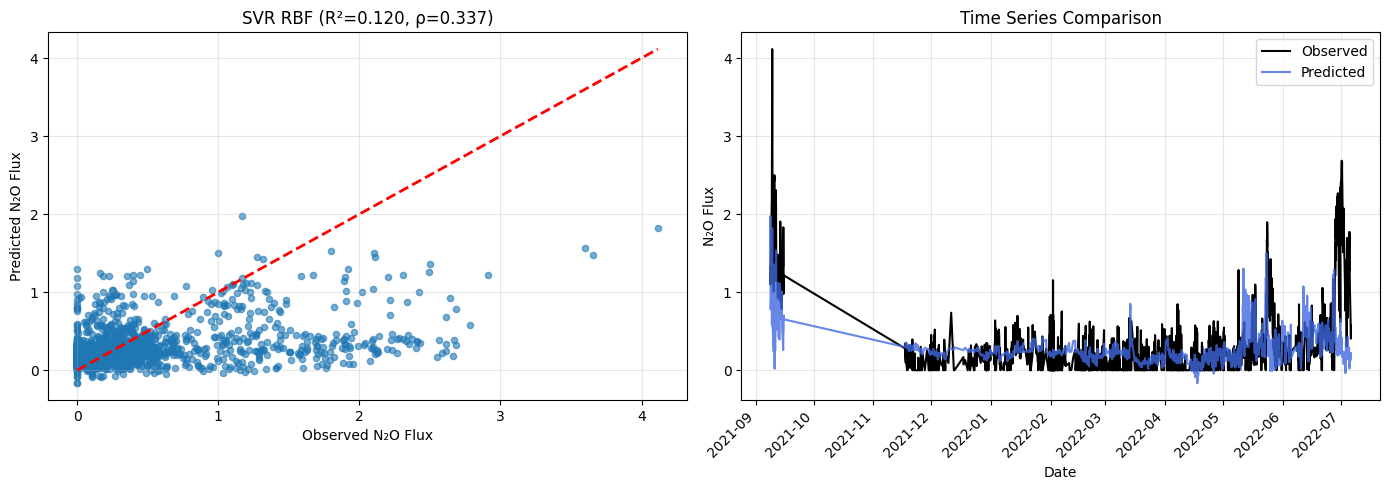


--- HOURLY | target=N2O_Flux_ln | predictors=LAG ---
Train period: 2014-01-01 08:15:00 → 2021-06-29 15:45:00
Test  period: 2021-06-29 17:15:00 → 2022-07-06 09:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): 0.334
  Spearman ρ:        0.481


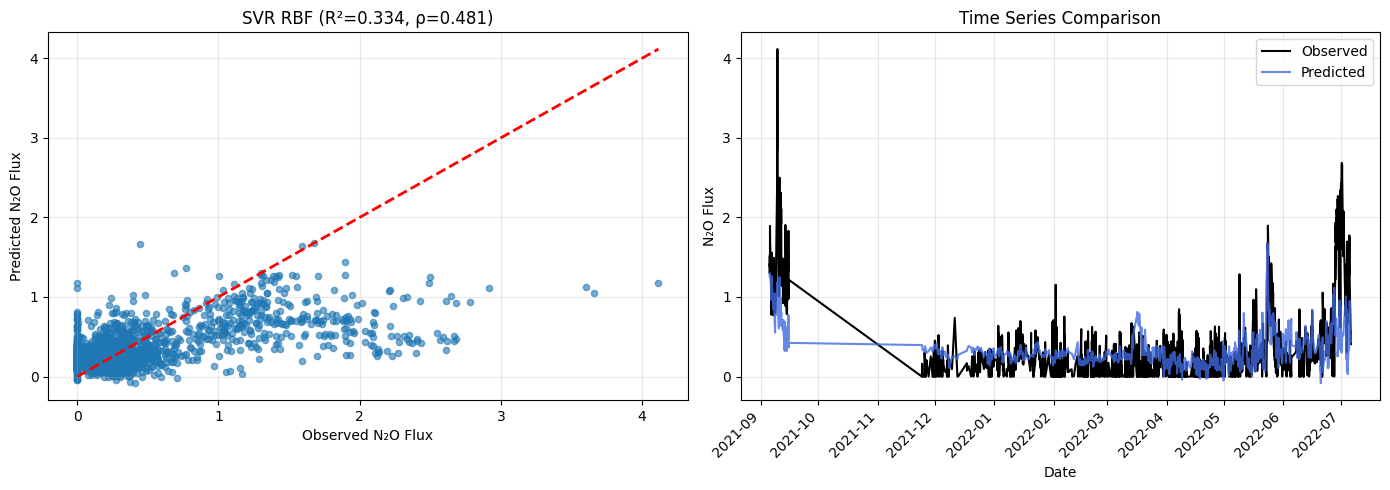


--- HOURLY | target=N2O_Flux_ln | predictors=AUGMENTED ---
Train period: 2014-01-01 08:15:00 → 2021-06-29 15:45:00
Test  period: 2021-06-29 17:15:00 → 2022-07-06 09:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): 0.324
  Spearman ρ:        0.465


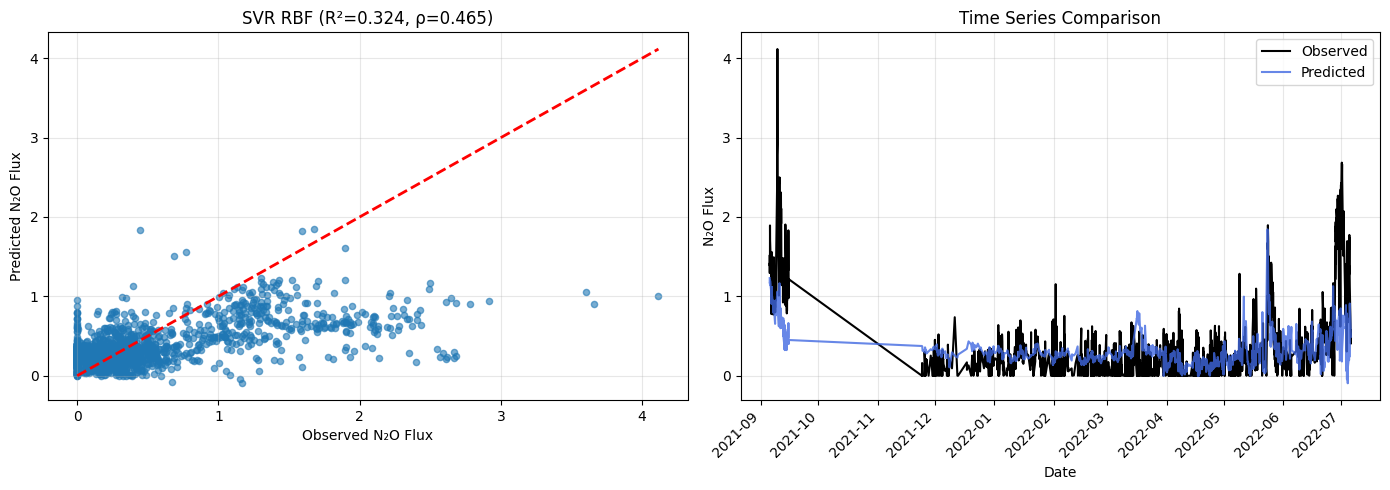


--- DAILY | target=N2O_Flux_ln | predictors=BASE ---
Train period: 2014-01-01 00:00:00 → 2021-08-10 00:00:00
Test  period: 2021-08-10 00:00:00 → 2022-07-06 00:00:00
  ✅ No data leakage detected

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -0.086
  Spearman ρ:        0.220


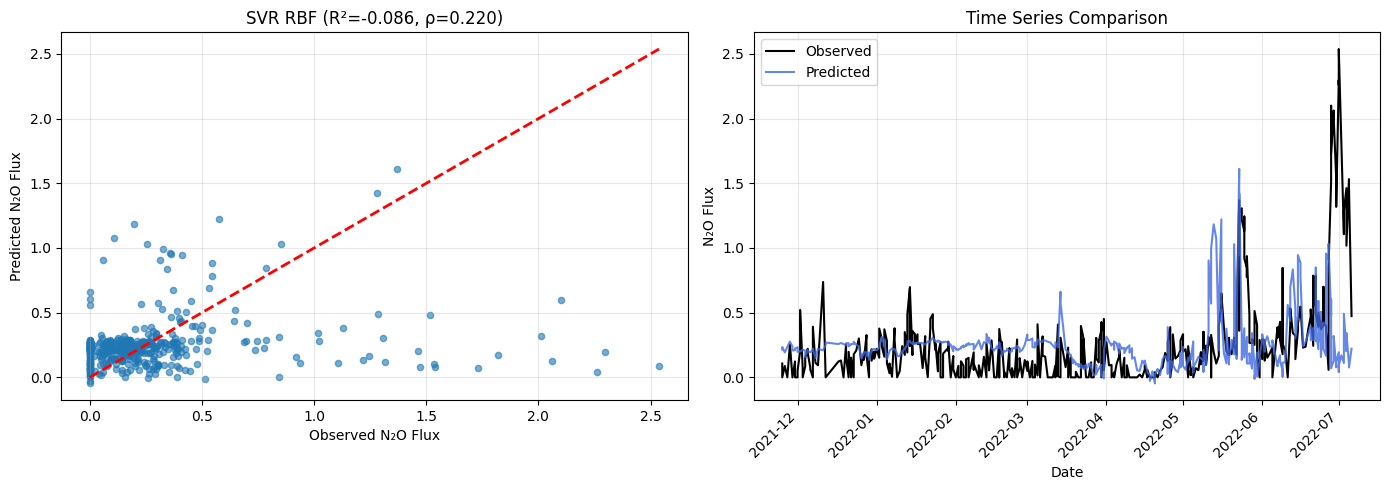


--- DAILY | target=N2O_Flux_ln | predictors=LAG ---
Train period: 2014-01-01 00:00:00 → 2021-07-22 00:00:00
Test  period: 2021-07-23 00:00:00 → 2022-07-06 00:00:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): 0.287
  Spearman ρ:        0.435


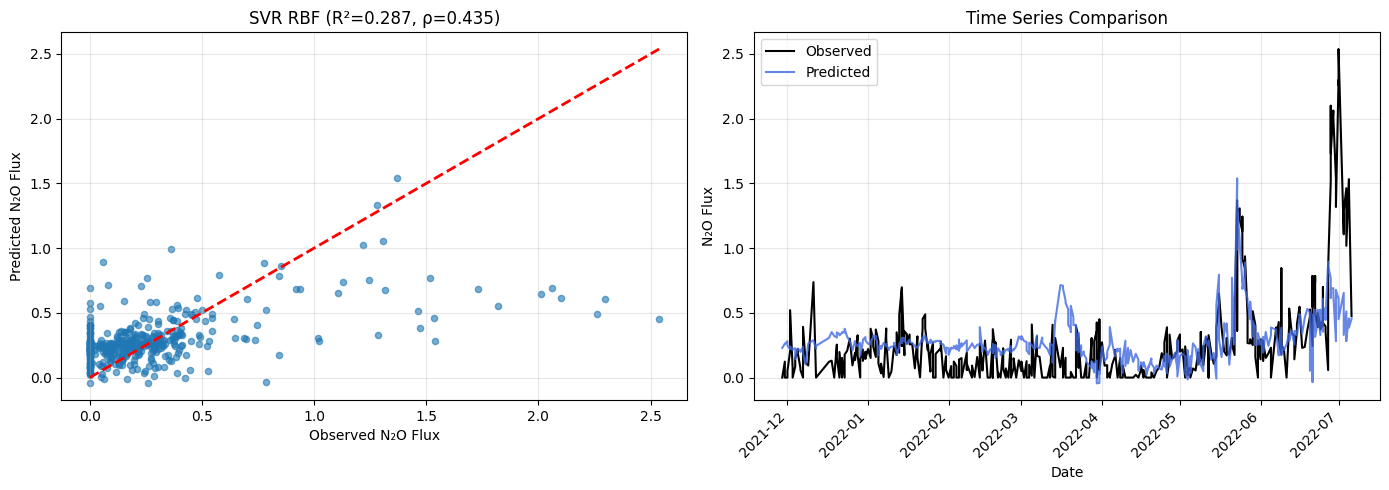


--- DAILY | target=N2O_Flux_ln | predictors=AUGMENTED ---
Train period: 2014-01-01 00:00:00 → 2021-07-22 00:00:00
Test  period: 2021-07-23 00:00:00 → 2022-07-06 00:00:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): 0.279
  Spearman ρ:        0.416


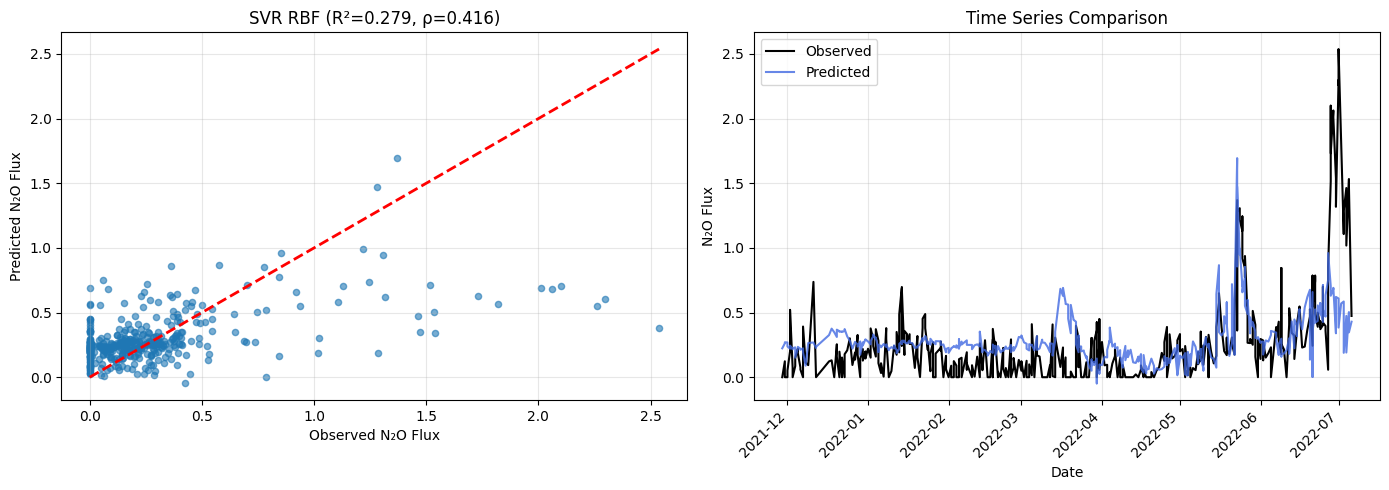


COMPREHENSIVE COMPARISON OF ALL EXPERIMENTS:
Temporal     Predictors   R²       Spearman ρ  
--------------------------------------------------------------------------------
Hourly       Base          0.120        0.337
Hourly       Lag           0.334        0.481
Hourly       Augmented     0.324        0.465
Daily        Base         -0.086        0.220
Daily        Lag           0.287        0.435
Daily        Augmented     0.279        0.416

IMPROVEMENT FROM BASE TO LAG:
Hourly: R² +  0.214, ρ +  0.144
Daily:  R² +  0.373, ρ +  0.215

IMPROVEMENT FROM LAG TO AUGMENTED:
Hourly: R² + -0.010, ρ + -0.016
Daily:  R² + -0.008, ρ + -0.019


In [21]:
# ============================================================================
# CHAMAU
# ============================================================================

print("="*80)
print("EXPERIMENT 4: Chamau 2014-2024")
print("="*80)

# Define base and lag predictors
base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm",
    "SoilTemp_4cm", "SoilTemp_15cm",
    "NEE", "GPP", "RECO",
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "Grazing", "SoilCultivation", "Fertilizer_N_kg_ha"
]

lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm",
    "SoilTemp_4cm", "SoilTemp_15cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilTemp_4cm_lag1d_daily", "SoilTemp_4cm_lag3d_daily", "SoilTemp_4cm_lag5d_daily", "SoilTemp_4cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "Grazing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_Grazing", "DaysSince_SoilCultivation", "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d" , "Fertilizer_N_kg_ha_expHL14d"
]

augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilTemp_4cm", "SoilTemp_15cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilTemp_4cm_lag1d_daily", "SoilTemp_4cm_lag3d_daily", "SoilTemp_4cm_lag5d_daily", "SoilTemp_4cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilTemp_4cm_roll3d_mean", "SoilTemp_4cm_roll5d_mean", "SoilTemp_4cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilTemp_4cm_roll3d_sum", "SoilTemp_4cm_roll5d_sum", "SoilTemp_4cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "Grazing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_Grazing", "DaysSince_SoilCultivation", "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d" , "Fertilizer_N_kg_ha_expHL14d"
]

# Store results for comparison
all_results = []

# ============================================================================
# HOURLY DATA - BASE PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=BASE ---")
print("="*80)

results_hourly_base = train_svr_timeseries(
    df=chamau_lag,
    predictors=base_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Base", results_hourly_base['r2'], results_hourly_base['spearman_rho']))


# ============================================================================
# HOURLY DATA - LAG PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=LAG ---")
print("="*80)

results_hourly_lag = train_svr_timeseries(
    df=chamau_lag,
    predictors=lag_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Lag", results_hourly_lag['r2'], results_hourly_lag['spearman_rho']))


# ============================================================================
# HOURLY DATA - AUGMENTED PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=AUGMENTED ---")
print("="*80)

results_hourly_augmented = train_svr_timeseries(
    df=chamau_lag,
    predictors=augmented_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Augmented", results_hourly_augmented['r2'], results_hourly_augmented['spearman_rho']))

# ============================================================================
# DAILY DATA - BASE PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=BASE ---")
print("="*80)

results_daily_base = train_svr_timeseries(
    df=chamau_daily,
    predictors=base_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Base", results_daily_base['r2'], results_daily_base['spearman_rho']))

# ============================================================================
# DAILY DATA - LAG PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=LAG ---")
print("="*80)

results_daily_lag = train_svr_timeseries(
    df=chamau_daily,
    predictors=lag_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Lag", results_daily_lag['r2'], results_daily_lag['spearman_rho']))


# ============================================================================
# DAILY DATA - AUGMENTED PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=AUGMENTED ---")
print("="*80)

results_daily_augmented = train_svr_timeseries(
    df=chamau_daily,
    predictors=augmented_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Augmented", results_daily_augmented['r2'], results_daily_augmented['spearman_rho']))

# ============================================================================
# COMPREHENSIVE COMPARISON
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON OF ALL EXPERIMENTS:")
print("="*80)
print(f"{'Temporal':<12} {'Predictors':<12} {'R²':<8} {'Spearman ρ':<12}")
print("-"*80)
for temp, pred, r2, rho in all_results:
    print(f"{temp:<12} {pred:<12} {r2:>6.3f}   {rho:>10.3f}")

print("\n" + "="*80)
print("IMPROVEMENT FROM BASE TO LAG:")
print("="*80)
print(f"Hourly: R² + {(results_hourly_lag['r2'] - results_hourly_base['r2']):>6.3f}, ρ + {(results_hourly_lag['spearman_rho'] - results_hourly_base['spearman_rho']):>6.3f}")
print(f"Daily:  R² + {(results_daily_lag['r2'] - results_daily_base['r2']):>6.3f}, ρ + {(results_daily_lag['spearman_rho'] - results_daily_base['spearman_rho']):>6.3f}")

print("\n" + "="*80)
print("IMPROVEMENT FROM LAG TO AUGMENTED:")
print("="*80)
print(f"Hourly: R² + {(results_hourly_augmented['r2'] - results_hourly_lag['r2']):>6.3f}, ρ + {(results_hourly_augmented['spearman_rho'] - results_hourly_lag['spearman_rho']):>6.3f}")
print(f"Daily:  R² + {(results_daily_augmented['r2'] - results_daily_lag['r2']):>6.3f}, ρ + {(results_daily_augmented['spearman_rho'] - results_daily_lag['spearman_rho']):>6.3f}")

# Experiment 2: Oensingen 2018-19

In [10]:
# FIX TIMESTAMP
oensingen_1_lag['Timestamp'] = pd.to_datetime(oensingen_1_lag['Timestamp'])
oensingen_1_lag = oensingen_1_lag.set_index('Timestamp').sort_index()

oensingen_1_daily['Date'] = pd.to_datetime(oensingen_1_daily['Date'])
oensingen_1_daily = oensingen_1_daily.set_index('Date').sort_index()

EXPERIMENT 2: Oensingen 2018-2019

--- HOURLY | target=N2O_Flux_ln | predictors=BASE ---
Train period: 2018-07-12 07:45:00 → 2019-09-09 01:45:00
Test  period: 2019-09-09 02:15:00 → 2019-10-04 23:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): 0.313
  Spearman ρ:        0.653


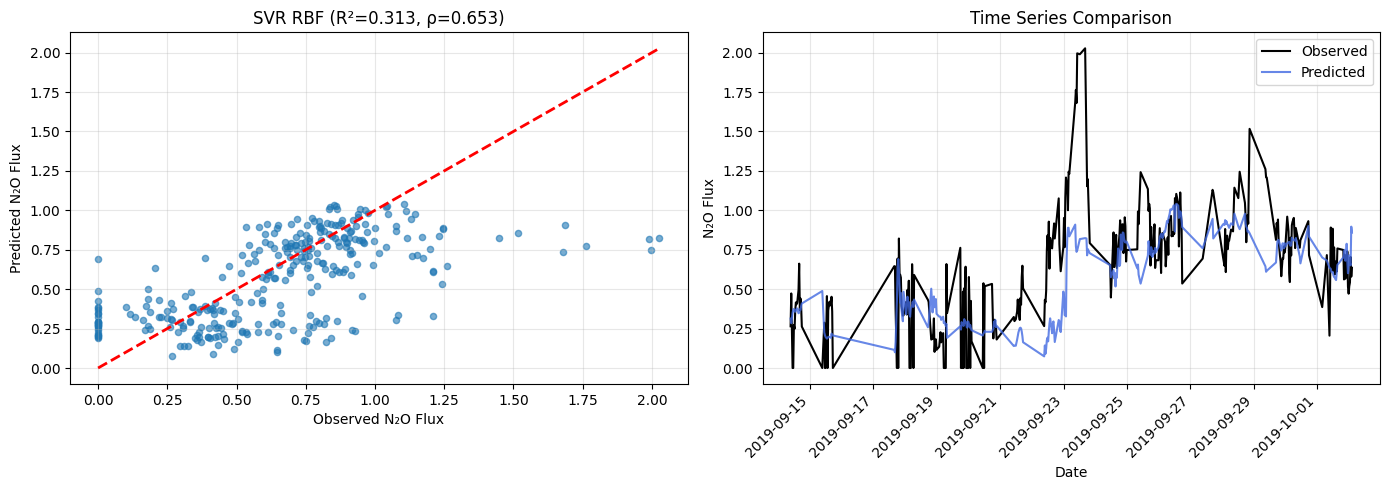


--- HOURLY | target=N2O_Flux_ln | predictors=LAG ---
Train period: 2018-07-12 07:45:00 → 2019-08-18 11:15:00
Test  period: 2019-08-18 11:45:00 → 2019-10-04 23:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -0.131
  Spearman ρ:        0.505


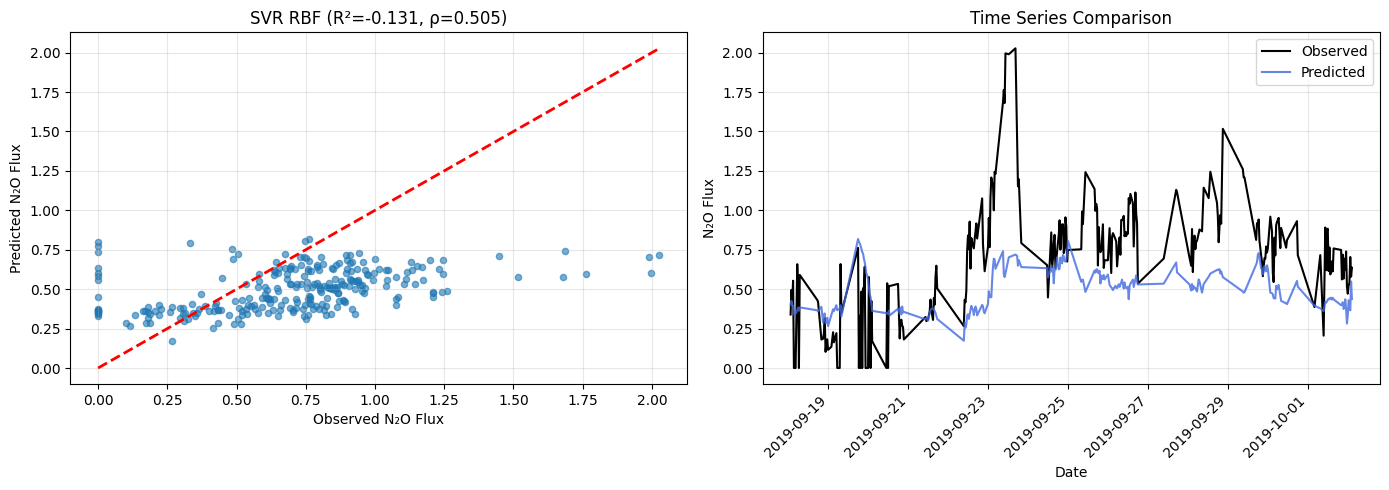


--- HOURLY | target=N2O_Flux_ln | predictors=AUGMENTED ---
Train period: 2018-07-12 07:45:00 → 2019-08-18 11:15:00
Test  period: 2019-08-18 11:45:00 → 2019-10-04 23:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -0.149
  Spearman ρ:        0.526


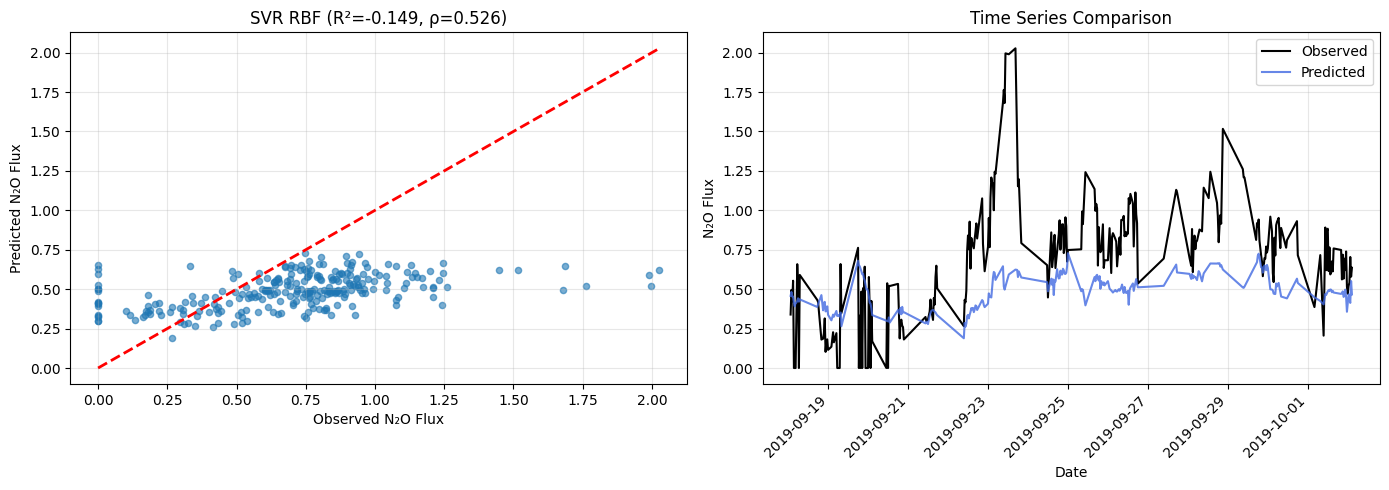


--- DAILY | target=N2O_Flux_ln | predictors=BASE ---
Train period: 2018-07-12 00:00:00 → 2019-09-12 00:00:00
Test  period: 2019-09-13 00:00:00 → 2019-10-04 00:00:00
  ✅ No data leakage detected

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): 0.480
  Spearman ρ:        0.715


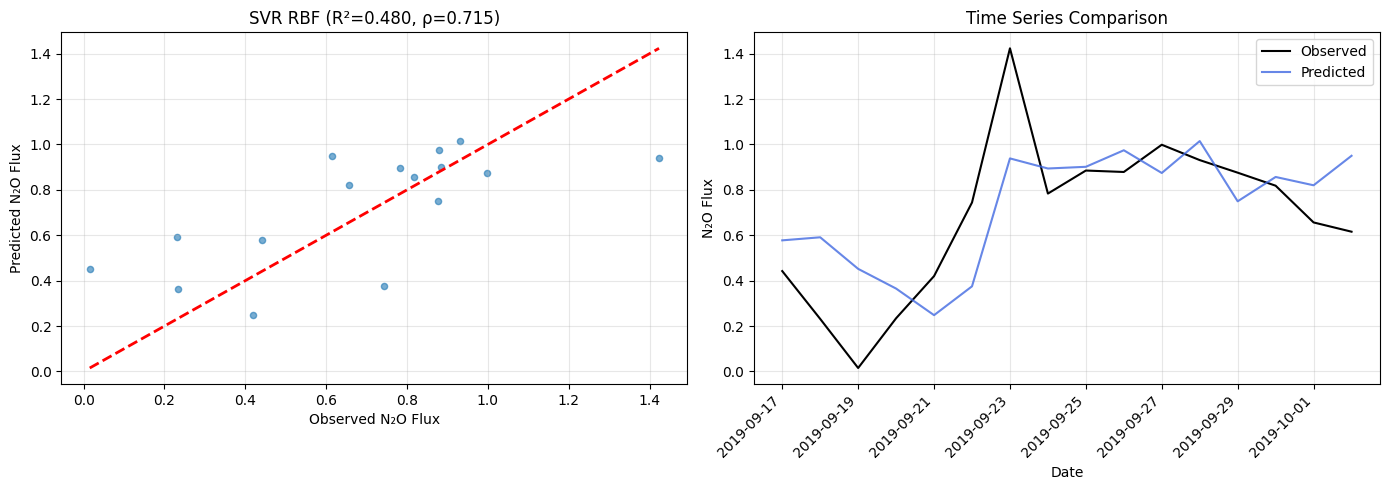


--- DAILY | target=N2O_Flux_ln | predictors=LAG ---
Train period: 2018-07-12 00:00:00 → 2019-08-30 00:00:00
Test  period: 2019-08-31 00:00:00 → 2019-10-04 00:00:00
  ✅ No data leakage detected

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -0.043
  Spearman ρ:        0.279


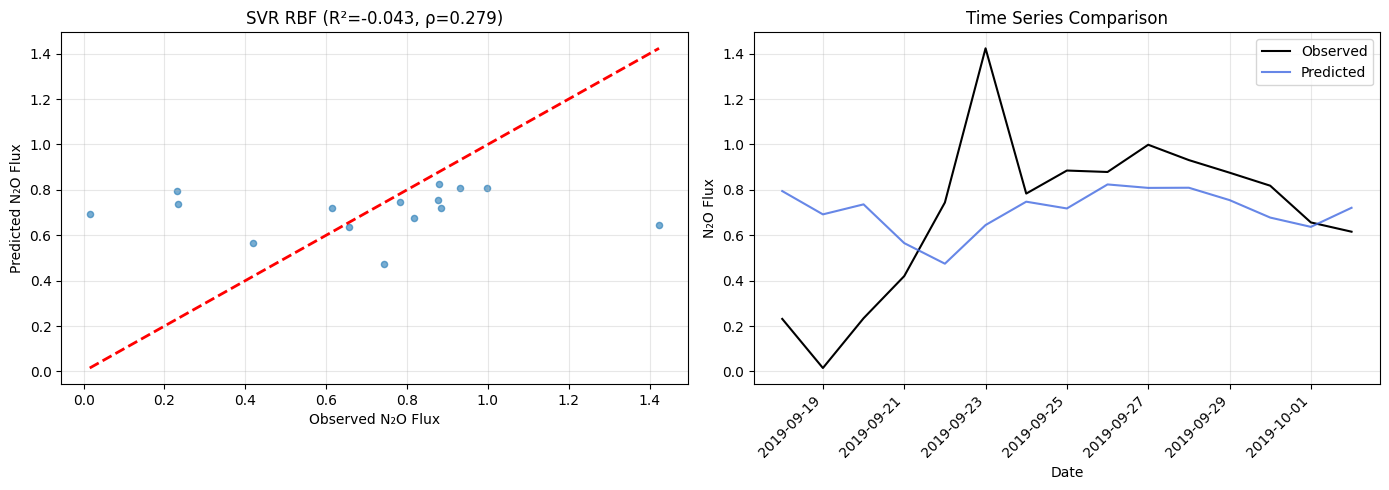


--- DAILY | target=N2O_Flux_ln | predictors=AUGMENTED ---
Train period: 2018-07-12 00:00:00 → 2019-08-30 00:00:00
Test  period: 2019-08-31 00:00:00 → 2019-10-04 00:00:00
  ✅ No data leakage detected

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -0.056
  Spearman ρ:        0.361


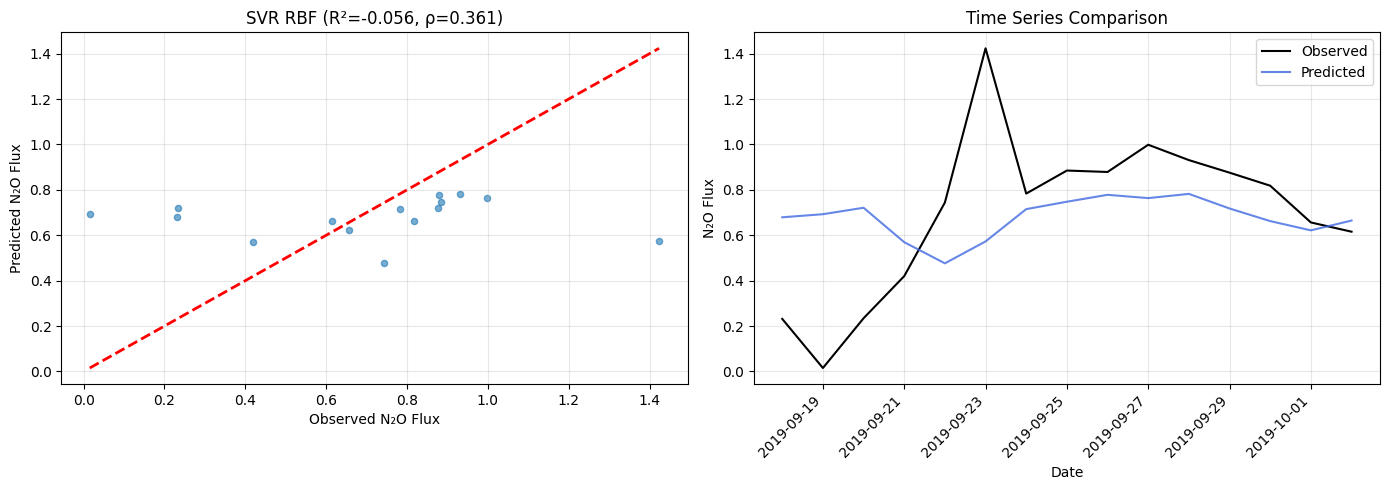


COMPREHENSIVE COMPARISON OF ALL EXPERIMENTS:
Temporal     Predictors   R²       Spearman ρ  
--------------------------------------------------------------------------------
Hourly       Base          0.313        0.653
Hourly       Lag          -0.131        0.505
Hourly       Augmented    -0.149        0.526
Daily        Base          0.480        0.715
Daily        Lag          -0.043        0.279
Daily        Augmented    -0.056        0.361

IMPROVEMENT FROM BASE TO LAG:
Hourly: R² + -0.444, ρ + -0.148
Daily:  R² + -0.524, ρ + -0.436

IMPROVEMENT FROM LAG TO AUGMENTED:
Hourly: R² + -0.017, ρ +  0.021
Daily:  R² + -0.013, ρ +  0.082


In [22]:
# ============================================================================
# OENSINGEN 1
# ============================================================================

print("="*80)
print("EXPERIMENT 2: Oensingen 2018-2019")
print("="*80)

# Define base and lag predictors
base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    "Mowing", "SoilCultivation"
]

hourly_lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",

    # --- Management variables ---
    "Mowing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_SoilCultivation"
]

hourly_augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # --- Management variables ---
    "Mowing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_SoilCultivation"
]

daily_lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",

    # --- Management variables ---
    "Mowing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_SoilCultivation"
]

daily_augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # --- Management variables ---
    "Mowing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_SoilCultivation"
]

# Store results for comparison
all_results = []

# ============================================================================
# HOURLY DATA - BASE PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=BASE ---")
print("="*80)

results_hourly_base = train_svr_timeseries(
    df=oensingen_1_lag,
    predictors=base_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Base", results_hourly_base['r2'], results_hourly_base['spearman_rho']))


# ============================================================================
# HOURLY DATA - LAG PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=LAG ---")
print("="*80)

results_hourly_lag = train_svr_timeseries(
    df=oensingen_1_lag,
    predictors=hourly_lag_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Lag", results_hourly_lag['r2'], results_hourly_lag['spearman_rho']))


# ============================================================================
# HOURLY DATA - AUGMENTED PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=AUGMENTED ---")
print("="*80)

results_hourly_augmented = train_svr_timeseries(
    df=oensingen_1_lag,
    predictors=hourly_augmented_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Augmented", results_hourly_augmented['r2'], results_hourly_augmented['spearman_rho']))

# ============================================================================
# DAILY DATA - BASE PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=BASE ---")
print("="*80)

results_daily_base = train_svr_timeseries(
    df=oensingen_1_daily,
    predictors=base_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Base", results_daily_base['r2'], results_daily_base['spearman_rho']))

# ============================================================================
# DAILY DATA - LAG PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=LAG ---")
print("="*80)

results_daily_lag = train_svr_timeseries(
    df=oensingen_1_daily,
    predictors=daily_lag_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Lag", results_daily_lag['r2'], results_daily_lag['spearman_rho']))


# ============================================================================
# DAILY DATA - AUGMENTED PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=AUGMENTED ---")
print("="*80)

results_daily_augmented = train_svr_timeseries(
    df=oensingen_1_daily,
    predictors=daily_augmented_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Augmented", results_daily_augmented['r2'], results_daily_augmented['spearman_rho']))

# ============================================================================
# COMPREHENSIVE COMPARISON
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON OF ALL EXPERIMENTS:")
print("="*80)
print(f"{'Temporal':<12} {'Predictors':<12} {'R²':<8} {'Spearman ρ':<12}")
print("-"*80)
for temp, pred, r2, rho in all_results:
    print(f"{temp:<12} {pred:<12} {r2:>6.3f}   {rho:>10.3f}")

print("\n" + "="*80)
print("IMPROVEMENT FROM BASE TO LAG:")
print("="*80)
print(f"Hourly: R² + {(results_hourly_lag['r2'] - results_hourly_base['r2']):>6.3f}, ρ + {(results_hourly_lag['spearman_rho'] - results_hourly_base['spearman_rho']):>6.3f}")
print(f"Daily:  R² + {(results_daily_lag['r2'] - results_daily_base['r2']):>6.3f}, ρ + {(results_daily_lag['spearman_rho'] - results_daily_base['spearman_rho']):>6.3f}")

print("\n" + "="*80)
print("IMPROVEMENT FROM LAG TO AUGMENTED:")
print("="*80)
print(f"Hourly: R² + {(results_hourly_augmented['r2'] - results_hourly_lag['r2']):>6.3f}, ρ + {(results_hourly_augmented['spearman_rho'] - results_hourly_lag['spearman_rho']):>6.3f}")
print(f"Daily:  R² + {(results_daily_augmented['r2'] - results_daily_lag['r2']):>6.3f}, ρ + {(results_daily_augmented['spearman_rho'] - results_daily_lag['spearman_rho']):>6.3f}")

# Experiment 3: Aeschi

In [12]:
# FIX TIMESTAMP
aeschi_lag['Timestamp'] = pd.to_datetime(aeschi_lag['Timestamp'])
aeschi_lag = aeschi_lag.set_index('Timestamp').sort_index()

aeschi_daily['Date'] = pd.to_datetime(aeschi_daily['Date'])
aeschi_daily = aeschi_daily.set_index('Date').sort_index()

EXPERIMENT 3: Aeschi 2019-2020

--- HOURLY | target=N2O_Flux_ln | predictors=BASE ---
Train period: 2019-05-10 00:15:00 → 2020-09-05 12:15:00
Test  period: 2020-09-05 13:45:00 → 2020-11-02 23:45:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -2.332
  Spearman ρ:        0.181


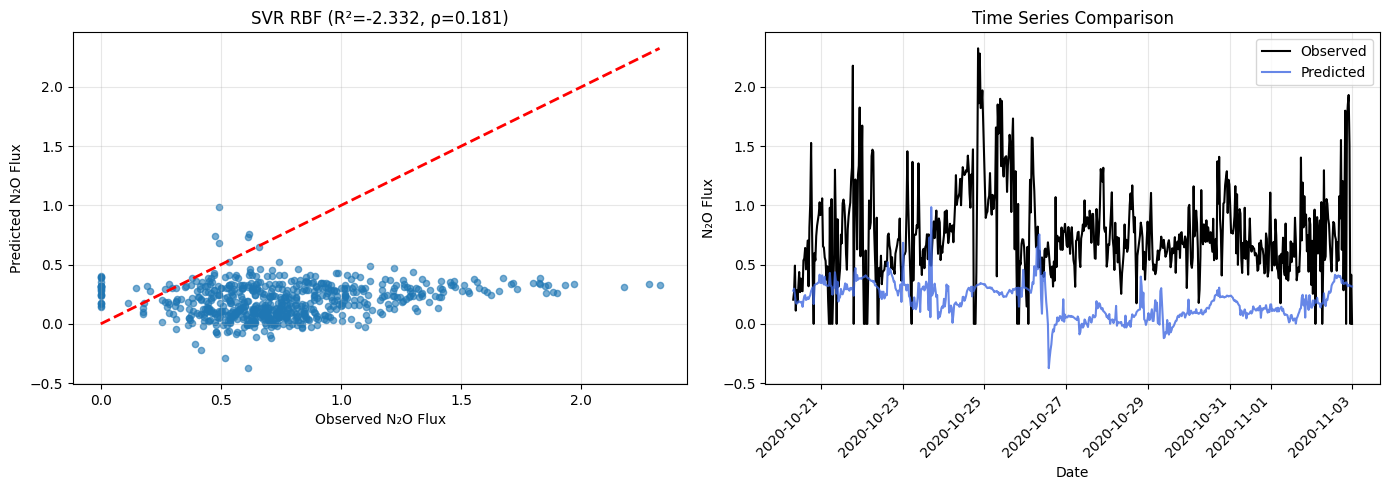


--- HOURLY | target=N2O_Flux_ln | predictors=LAG ---
Train period: 2019-05-10 00:15:00 → 2020-08-18 21:15:00
Test  period: 2020-08-18 21:45:00 → 2020-11-02 23:45:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -1.201
  Spearman ρ:        0.154


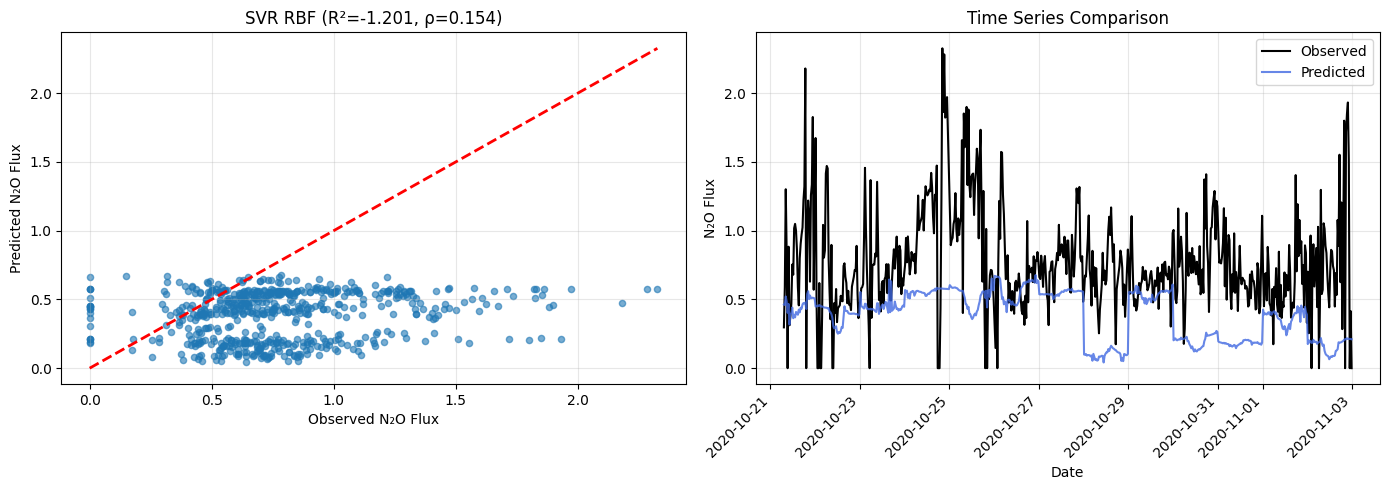


--- HOURLY | target=N2O_Flux_ln | predictors=AUGMENTED ---
Train period: 2019-05-10 00:15:00 → 2020-08-18 21:15:00
Test  period: 2020-08-18 21:45:00 → 2020-11-02 23:45:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -0.627
  Spearman ρ:        0.150


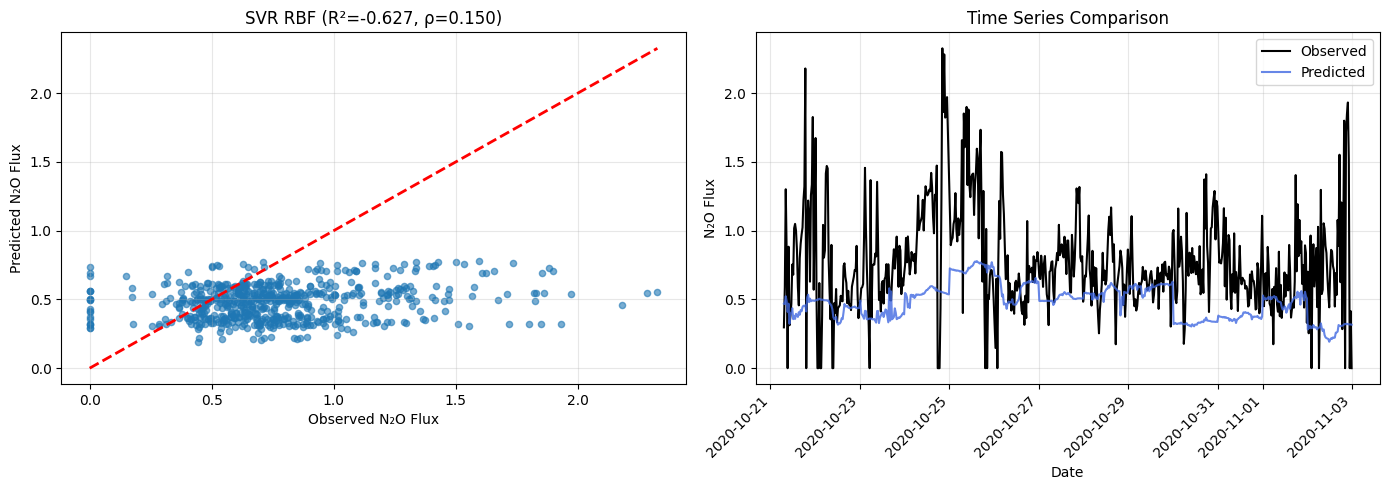


--- DAILY | target=N2O_Flux_ln | predictors=BASE ---
Train period: 2019-05-10 00:00:00 → 2020-09-29 00:00:00
Test  period: 2020-09-30 00:00:00 → 2020-11-02 00:00:00
  ✅ No data leakage detected

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -0.536
  Spearman ρ:        -0.485


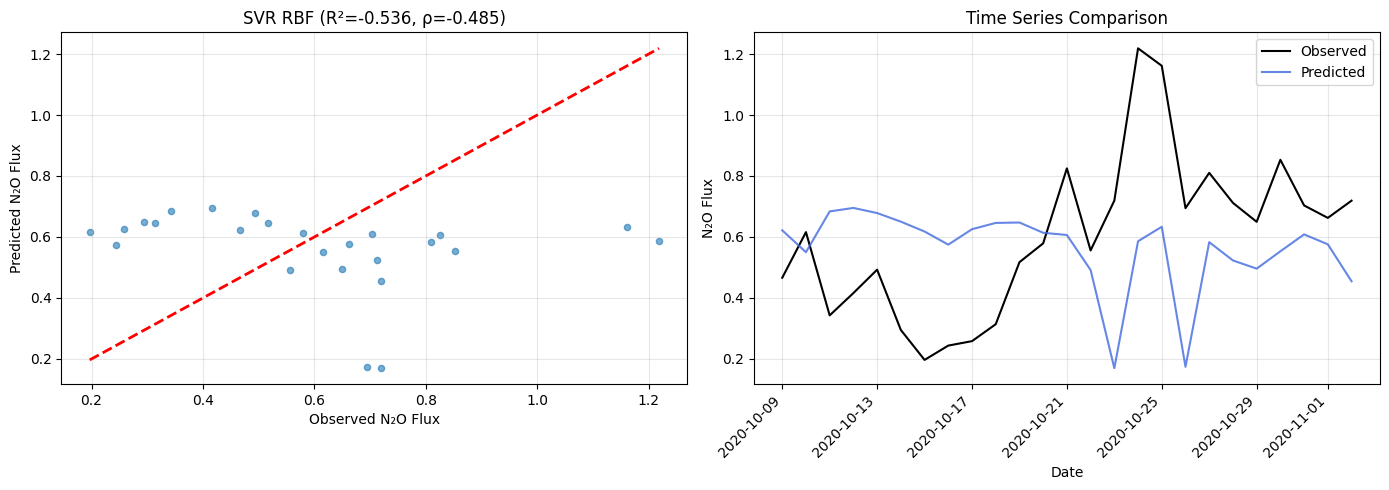


--- DAILY | target=N2O_Flux_ln | predictors=LAG ---
Train period: 2019-05-10 00:00:00 → 2020-09-20 00:00:00
Test  period: 2020-09-21 00:00:00 → 2020-11-02 00:00:00
  ✅ No data leakage detected

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -1.176
  Spearman ρ:        -0.622


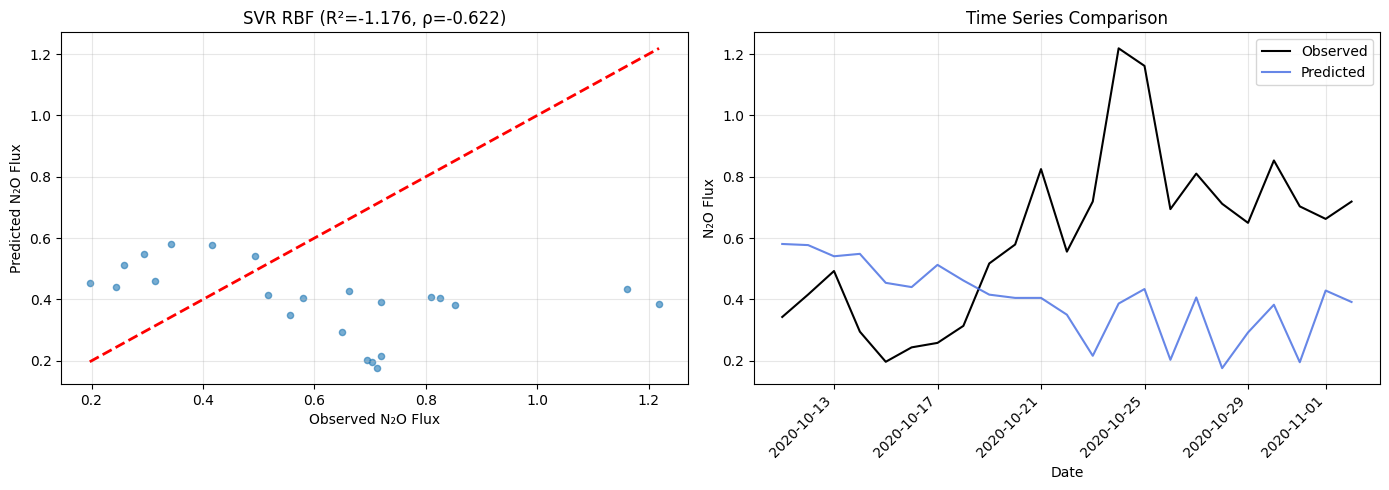


--- DAILY | target=N2O_Flux_ln | predictors=AUGMENTED ---
Train period: 2019-05-10 00:00:00 → 2020-09-20 00:00:00
Test  period: 2020-09-21 00:00:00 → 2020-11-02 00:00:00
  ✅ No data leakage detected

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -0.950
  Spearman ρ:        -0.382


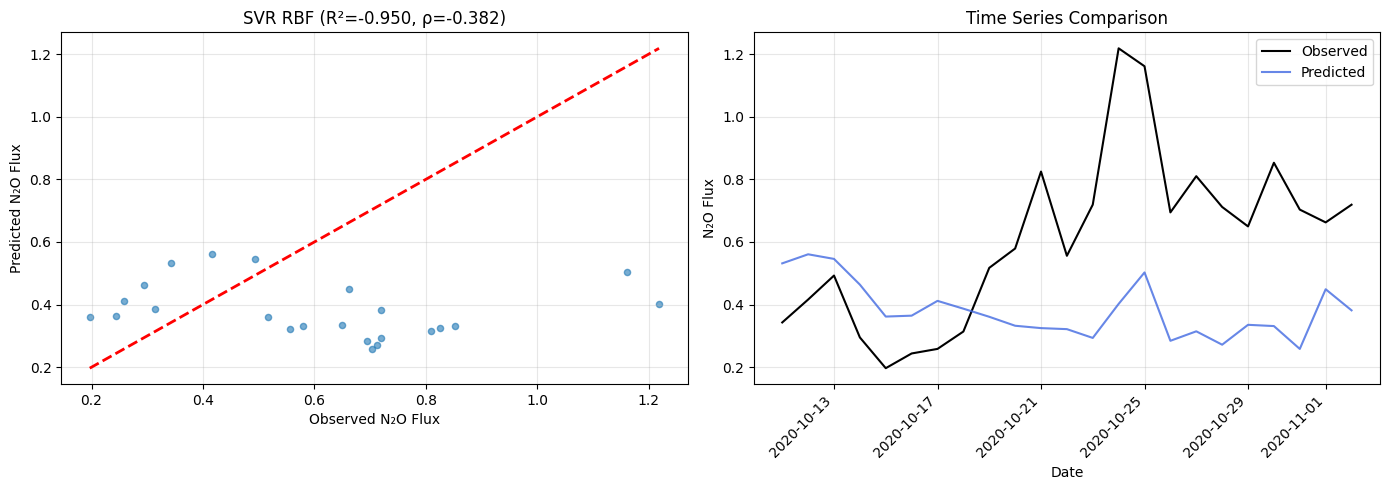


COMPREHENSIVE COMPARISON OF ALL EXPERIMENTS:
Temporal     Predictors   R²       Spearman ρ  
--------------------------------------------------------------------------------
Hourly       Base         -2.332        0.181
Hourly       Lag          -1.201        0.154
Hourly       Augmented    -0.627        0.150
Daily        Base         -0.536       -0.485
Daily        Lag          -1.176       -0.622
Daily        Augmented    -0.950       -0.382

IMPROVEMENT FROM BASE TO LAG:
Hourly: R² +  1.131, ρ + -0.026
Daily:  R² + -0.640, ρ + -0.137

IMPROVEMENT FROM LAG TO AUGMENTED:
Hourly: R² +  0.574, ρ + -0.005
Daily:  R² +  0.226, ρ +  0.239


In [23]:
# ============================================================================
# AESCHI
# ============================================================================

print("="*80)
print("EXPERIMENT 3: Aeschi 2019-2020")
print("="*80)

# Define base and lag predictors
base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    "Mowing"
]

lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",

    # --- Management variables ---
    "Mowing", "DaysSince_Mowing"
]

augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # --- Management variables ---
    "Mowing", "DaysSince_Mowing",
]

# Store results for comparison
all_results = []

# ============================================================================
# HOURLY DATA - BASE PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=BASE ---")
print("="*80)

results_hourly_base = train_svr_timeseries(
    df=aeschi_lag,
    predictors=base_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Base", results_hourly_base['r2'], results_hourly_base['spearman_rho']))


# ============================================================================
# HOURLY DATA - LAG PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=LAG ---")
print("="*80)

results_hourly_lag = train_svr_timeseries(
    df=aeschi_lag,
    predictors=lag_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Lag", results_hourly_lag['r2'], results_hourly_lag['spearman_rho']))


# ============================================================================
# HOURLY DATA - AUGMENTED PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=AUGMENTED ---")
print("="*80)

results_hourly_augmented = train_svr_timeseries(
    df=aeschi_lag,
    predictors=augmented_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Augmented", results_hourly_augmented['r2'], results_hourly_augmented['spearman_rho']))

# ============================================================================
# DAILY DATA - BASE PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=BASE ---")
print("="*80)

results_daily_base = train_svr_timeseries(
    df=aeschi_daily,
    predictors=base_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Base", results_daily_base['r2'], results_daily_base['spearman_rho']))

# ============================================================================
# DAILY DATA - LAG PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=LAG ---")
print("="*80)

results_daily_lag = train_svr_timeseries(
    df=aeschi_daily,
    predictors=lag_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Lag", results_daily_lag['r2'], results_daily_lag['spearman_rho']))


# ============================================================================
# DAILY DATA - AUGMENTED PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=AUGMENTED ---")
print("="*80)

results_daily_augmented = train_svr_timeseries(
    df=aeschi_daily,
    predictors=augmented_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Augmented", results_daily_augmented['r2'], results_daily_augmented['spearman_rho']))

# ============================================================================
# COMPREHENSIVE COMPARISON
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON OF ALL EXPERIMENTS:")
print("="*80)
print(f"{'Temporal':<12} {'Predictors':<12} {'R²':<8} {'Spearman ρ':<12}")
print("-"*80)
for temp, pred, r2, rho in all_results:
    print(f"{temp:<12} {pred:<12} {r2:>6.3f}   {rho:>10.3f}")

print("\n" + "="*80)
print("IMPROVEMENT FROM BASE TO LAG:")
print("="*80)
print(f"Hourly: R² + {(results_hourly_lag['r2'] - results_hourly_base['r2']):>6.3f}, ρ + {(results_hourly_lag['spearman_rho'] - results_hourly_base['spearman_rho']):>6.3f}")
print(f"Daily:  R² + {(results_daily_lag['r2'] - results_daily_base['r2']):>6.3f}, ρ + {(results_daily_lag['spearman_rho'] - results_daily_base['spearman_rho']):>6.3f}")

print("\n" + "="*80)
print("IMPROVEMENT FROM LAG TO AUGMENTED:")
print("="*80)
print(f"Hourly: R² + {(results_hourly_augmented['r2'] - results_hourly_lag['r2']):>6.3f}, ρ + {(results_hourly_augmented['spearman_rho'] - results_hourly_lag['spearman_rho']):>6.3f}")
print(f"Daily:  R² + {(results_daily_augmented['r2'] - results_daily_lag['r2']):>6.3f}, ρ + {(results_daily_augmented['spearman_rho'] - results_daily_lag['spearman_rho']):>6.3f}")

# Experiment 4: Oensingen 2021-23

In [28]:
# FIX TIMESTAMP
oensingen_2_lag['Timestamp'] = pd.to_datetime(oensingen_2_lag['Timestamp'])
oensingen_2_lag = oensingen_2_lag.set_index('Timestamp').sort_index()

oensingen_2_daily['Date'] = pd.to_datetime(oensingen_2_daily['Date'])
oensingen_2_daily = oensingen_2_daily.set_index('Date').sort_index()

EXPERIMENT 4: Oensingen 2021-2023

--- HOURLY | target=N2O_Flux_ln | predictors=BASE ---
Train period: 2022-08-30 11:45:00 → 2023-08-15 09:15:00
Test  period: 2023-08-15 14:45:00 → 2023-10-05 12:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -0.401
  Spearman ρ:        0.360


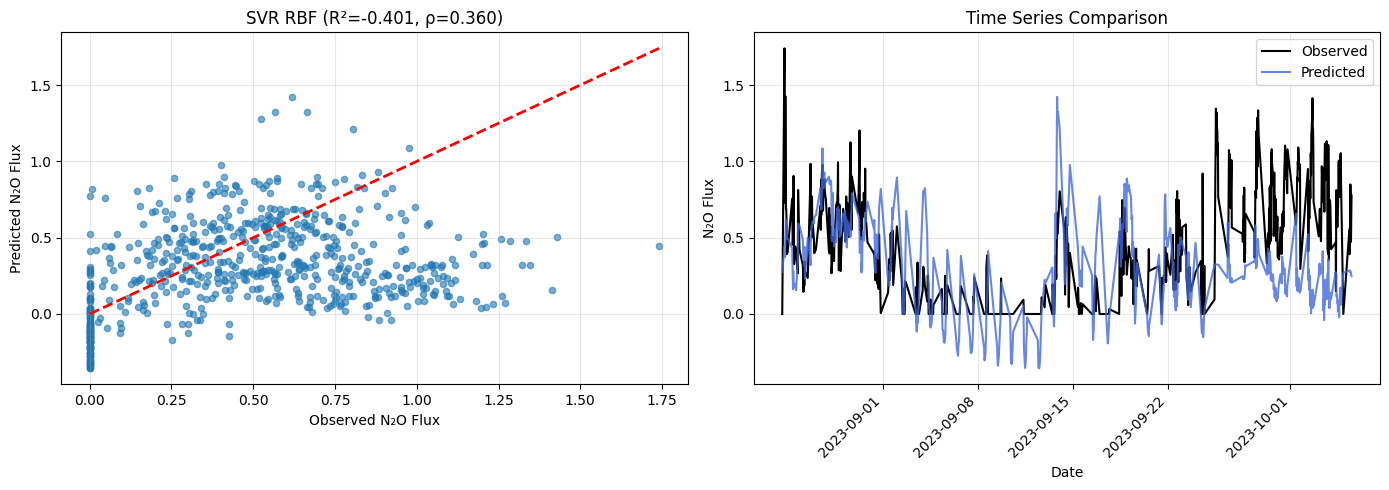


--- HOURLY | target=N2O_Flux_ln | predictors=LAG ---
Train period: 2022-08-30 11:45:00 → 2023-08-15 09:15:00
Test  period: 2023-08-15 14:45:00 → 2023-10-05 12:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -0.318
  Spearman ρ:        0.470


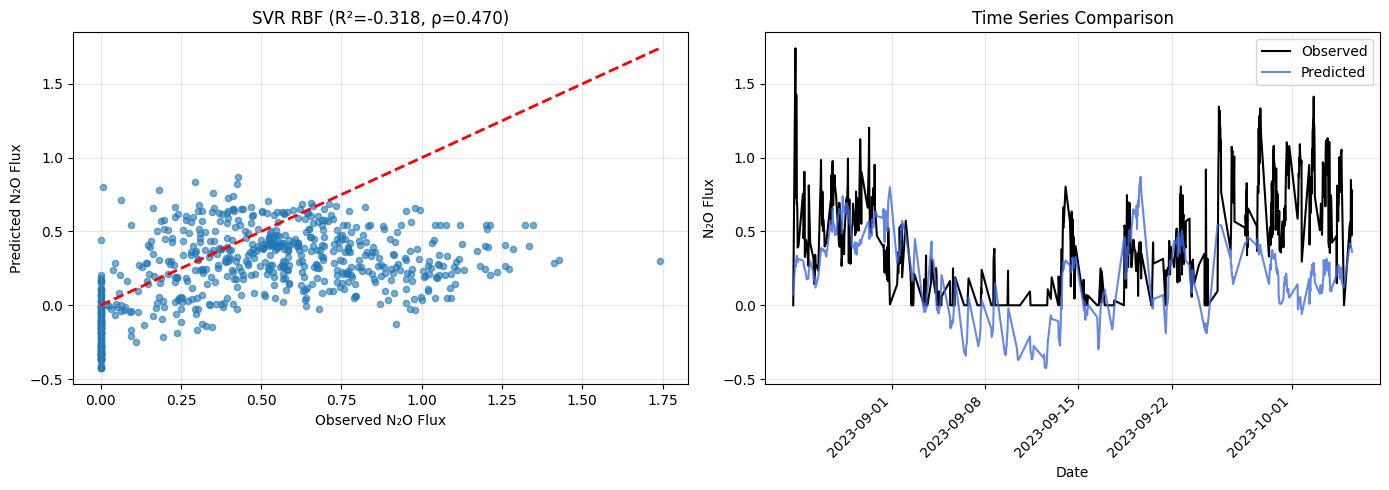


--- HOURLY | target=N2O_Flux_ln | predictors=AUGMENTED ---
Train period: 2022-08-30 11:45:00 → 2023-08-15 09:15:00
Test  period: 2023-08-15 14:45:00 → 2023-10-05 12:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -0.410
  Spearman ρ:        0.490


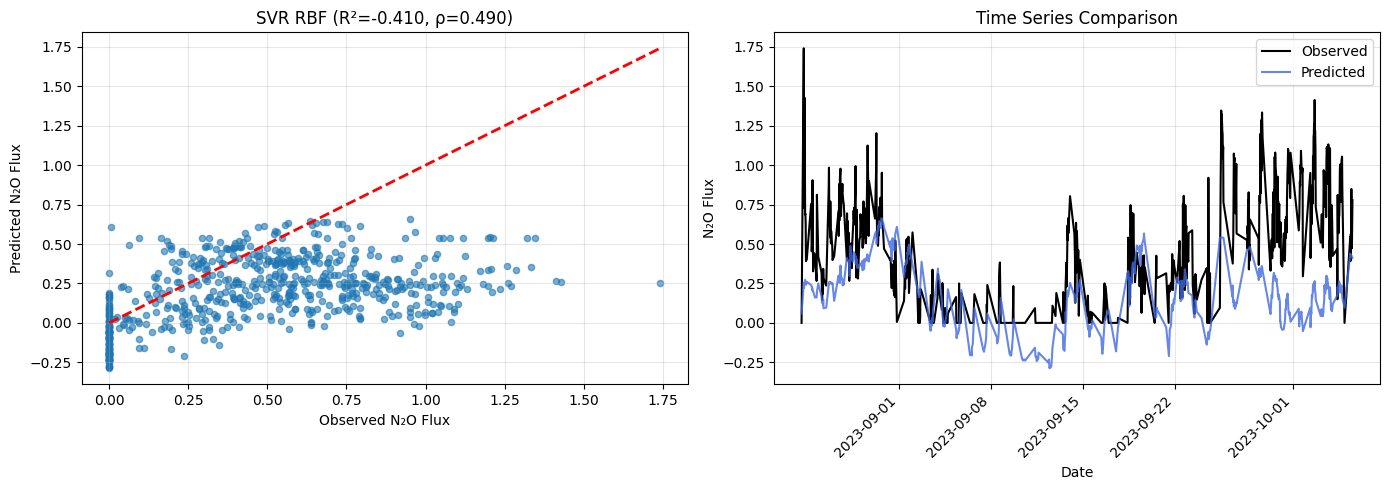


--- DAILY | target=N2O_Flux_ln | predictors=BASE ---
Train period: 2022-08-30 00:00:00 → 2023-08-28 00:00:00
Test  period: 2023-08-29 00:00:00 → 2023-10-05 00:00:00
  ✅ No data leakage detected

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): 0.437
  Spearman ρ:        0.822


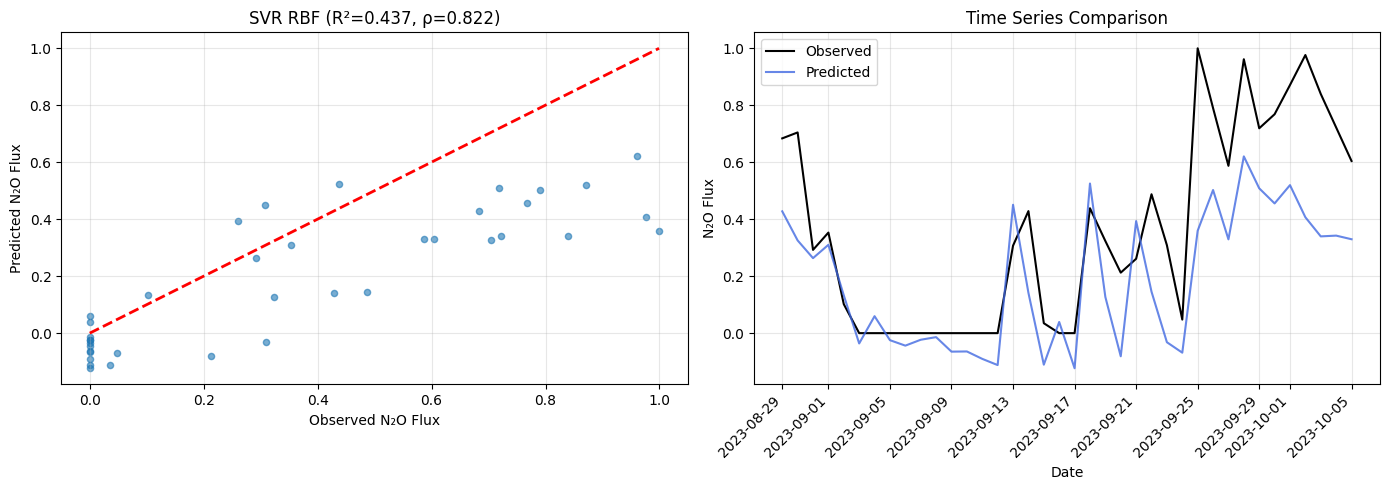


--- DAILY | target=N2O_Flux_ln | predictors=LAG ---
Train period: 2022-08-30 00:00:00 → 2023-08-22 00:00:00
Test  period: 2023-08-23 00:00:00 → 2023-10-05 00:00:00
  ✅ No data leakage detected

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): 0.515
  Spearman ρ:        0.870


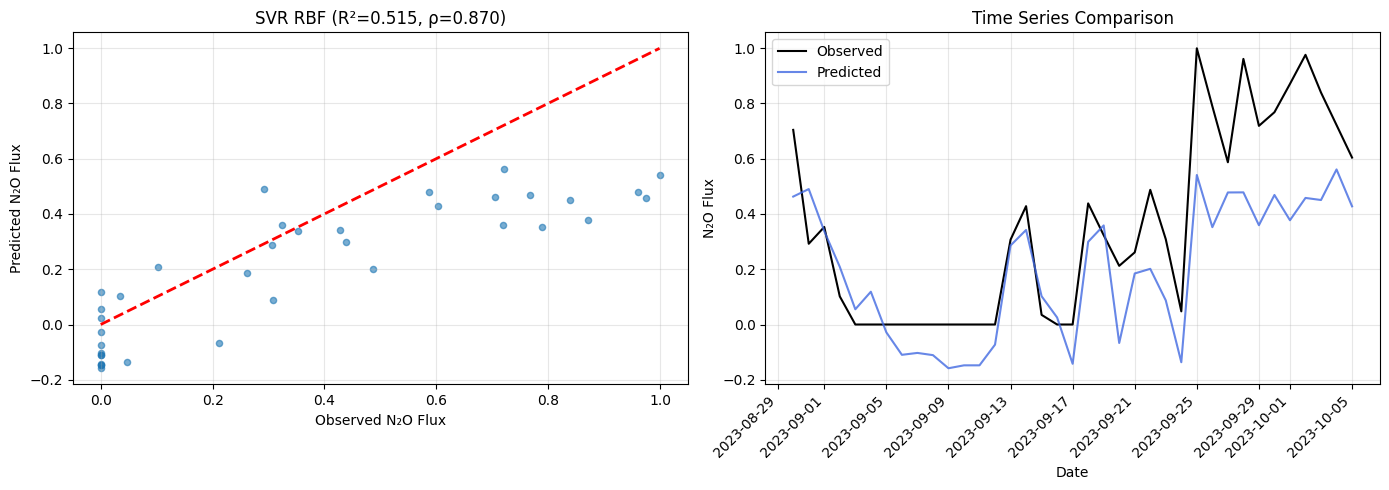


--- DAILY | target=N2O_Flux_ln | predictors=AUGMENTED ---
Train period: 2022-08-30 00:00:00 → 2023-08-22 00:00:00
Test  period: 2023-08-23 00:00:00 → 2023-10-05 00:00:00
  ✅ No data leakage detected

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): 0.423
  Spearman ρ:        0.809


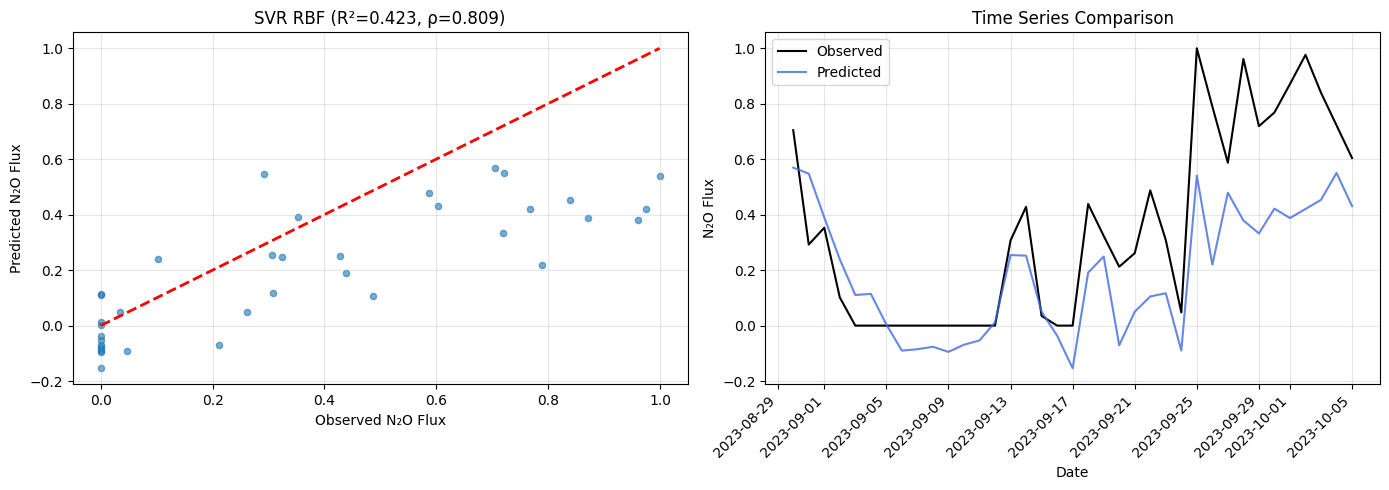


COMPREHENSIVE COMPARISON OF ALL EXPERIMENTS:
Temporal     Predictors   R²       Spearman ρ  
--------------------------------------------------------------------------------
Hourly       Base         -0.401        0.360
Hourly       Lag          -0.318        0.470
Hourly       Augmented    -0.410        0.490
Daily        Base          0.437        0.822
Daily        Lag           0.515        0.870
Daily        Augmented     0.423        0.809

IMPROVEMENT FROM BASE TO LAG:
Hourly: R² +  0.082, ρ +  0.110
Daily:  R² +  0.077, ρ +  0.048

IMPROVEMENT FROM LAG TO AUGMENTED:
Hourly: R² + -0.092, ρ +  0.020
Daily:  R² + -0.092, ρ + -0.060


In [31]:
# ============================================================================
# OENSINGEN 2
# ============================================================================

print("="*80)
print("EXPERIMENT 4: Oensingen 2021-2023")
print("="*80)

# Define base and lag predictors
base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation", "Fertilizer_N_kg_ha"
]

hourly_lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation", "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d" , "Fertilizer_N_kg_ha_expHL14d"
]

hourly_augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # Management events and days since
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation", "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d" , "Fertilizer_N_kg_ha_expHL14d"
]

daily_lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation", "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d" , "Fertilizer_N_kg_ha_expHL14d"
]

daily_augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # Management events and days since
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation", "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d" , "Fertilizer_N_kg_ha_expHL14d"
]

# Store results for comparison
all_results = []

# ============================================================================
# HOURLY DATA - BASE PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=BASE ---")
print("="*80)

results_hourly_base = train_svr_timeseries(
    df=oensingen_2_lag,
    predictors=base_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Base", results_hourly_base['r2'], results_hourly_base['spearman_rho']))


# ============================================================================
# HOURLY DATA - LAG PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=LAG ---")
print("="*80)

results_hourly_lag = train_svr_timeseries(
    df=oensingen_2_lag,
    predictors=hourly_lag_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Lag", results_hourly_lag['r2'], results_hourly_lag['spearman_rho']))


# ============================================================================
# HOURLY DATA - AUGMENTED PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=AUGMENTED ---")
print("="*80)

results_hourly_augmented = train_svr_timeseries(
    df=oensingen_2_lag,
    predictors=hourly_augmented_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Augmented", results_hourly_augmented['r2'], results_hourly_augmented['spearman_rho']))

# ============================================================================
# DAILY DATA - BASE PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=BASE ---")
print("="*80)

results_daily_base = train_svr_timeseries(
    df=oensingen_2_daily,
    predictors=base_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Base", results_daily_base['r2'], results_daily_base['spearman_rho']))

# ============================================================================
# DAILY DATA - LAG PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=LAG ---")
print("="*80)

results_daily_lag = train_svr_timeseries(
    df=oensingen_2_daily,
    predictors=daily_lag_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Lag", results_daily_lag['r2'], results_daily_lag['spearman_rho']))


# ============================================================================
# DAILY DATA - AUGMENTED PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=AUGMENTED ---")
print("="*80)

results_daily_augmented = train_svr_timeseries(
    df=oensingen_2_daily,
    predictors=daily_augmented_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Augmented", results_daily_augmented['r2'], results_daily_augmented['spearman_rho']))

# ============================================================================
# COMPREHENSIVE COMPARISON
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON OF ALL EXPERIMENTS:")
print("="*80)
print(f"{'Temporal':<12} {'Predictors':<12} {'R²':<8} {'Spearman ρ':<12}")
print("-"*80)
for temp, pred, r2, rho in all_results:
    print(f"{temp:<12} {pred:<12} {r2:>6.3f}   {rho:>10.3f}")

print("\n" + "="*80)
print("IMPROVEMENT FROM BASE TO LAG:")
print("="*80)
print(f"Hourly: R² + {(results_hourly_lag['r2'] - results_hourly_base['r2']):>6.3f}, ρ + {(results_hourly_lag['spearman_rho'] - results_hourly_base['spearman_rho']):>6.3f}")
print(f"Daily:  R² + {(results_daily_lag['r2'] - results_daily_base['r2']):>6.3f}, ρ + {(results_daily_lag['spearman_rho'] - results_daily_base['spearman_rho']):>6.3f}")

print("\n" + "="*80)
print("IMPROVEMENT FROM LAG TO AUGMENTED:")
print("="*80)
print(f"Hourly: R² + {(results_hourly_augmented['r2'] - results_hourly_lag['r2']):>6.3f}, ρ + {(results_hourly_augmented['spearman_rho'] - results_hourly_lag['spearman_rho']):>6.3f}")
print(f"Daily:  R² + {(results_daily_augmented['r2'] - results_daily_lag['r2']):>6.3f}, ρ + {(results_daily_augmented['spearman_rho'] - results_daily_lag['spearman_rho']):>6.3f}")

# Experiment 5: Forel

In [32]:
# FIX TIMESTAMP
forel_lag['Timestamp'] = pd.to_datetime(forel_lag['Timestamp'])
forel_lag = forel_lag.set_index('Timestamp').sort_index()

forel_daily['Date'] = pd.to_datetime(forel_daily['Date'])
forel_daily = forel_daily.set_index('Date').sort_index()

EXPERIMENT 5: Forel 2024-2025

--- HOURLY | target=N2O_Flux_ln | predictors=BASE ---
Train period: 2024-03-07 21:15:00 → 2025-03-01 19:15:00
Test  period: 2025-03-01 19:45:00 → 2025-05-03 13:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): 0.111
  Spearman ρ:        0.428


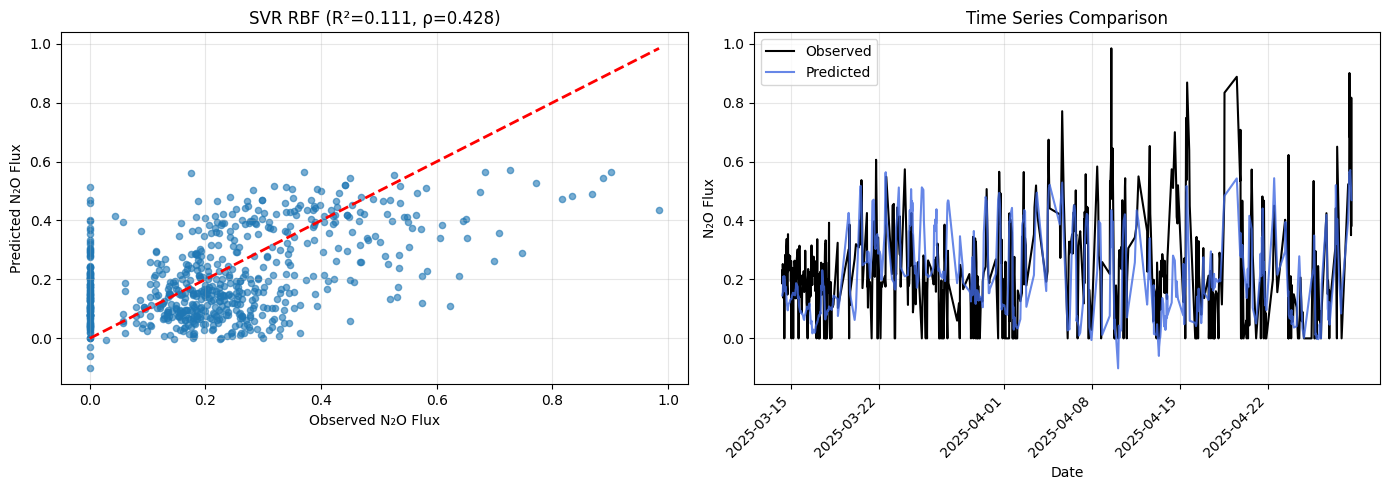


--- HOURLY | target=N2O_Flux_ln | predictors=LAG ---
Train period: 2024-03-07 21:15:00 → 2025-02-17 21:15:00
Test  period: 2025-02-18 03:15:00 → 2025-05-03 13:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -0.001
  Spearman ρ:        0.337


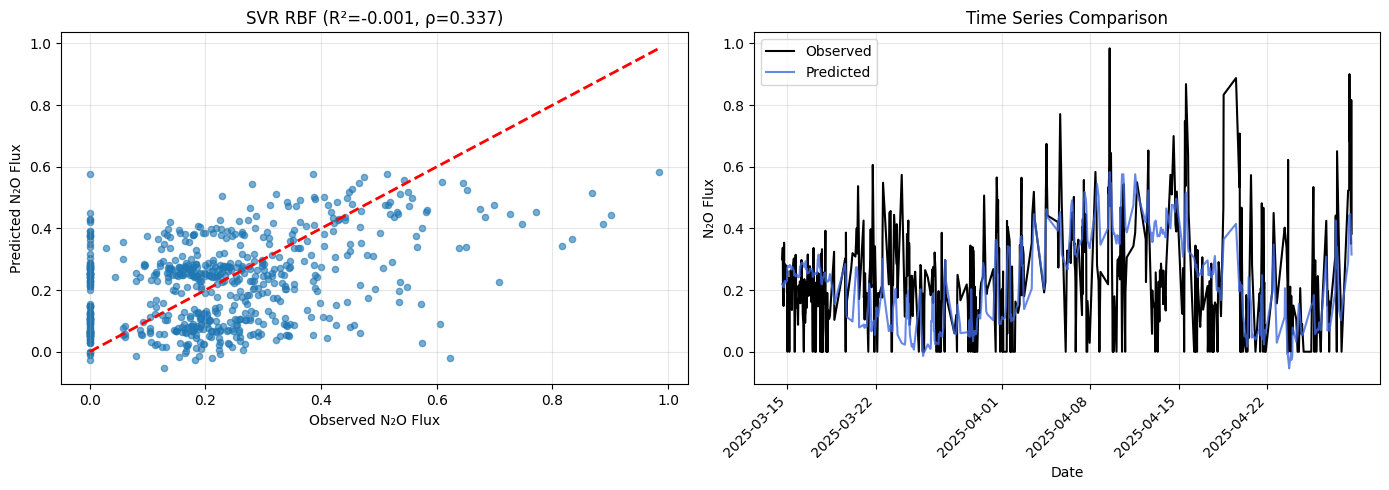


--- HOURLY | target=N2O_Flux_ln | predictors=AUGMENTED ---
Train period: 2024-03-07 21:15:00 → 2025-02-17 21:15:00
Test  period: 2025-02-18 03:15:00 → 2025-05-03 13:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): 0.156
  Spearman ρ:        0.395


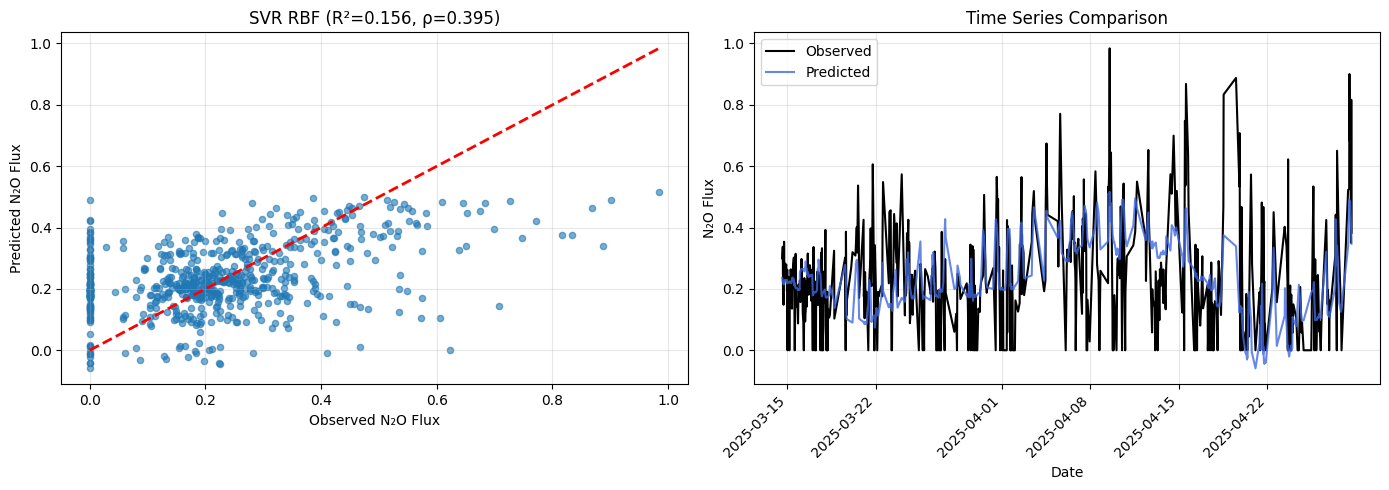


--- DAILY | target=N2O_Flux_ln | predictors=BASE ---
Train period: 2024-03-07 00:00:00 → 2025-03-11 00:00:00
Test  period: 2025-03-12 00:00:00 → 2025-05-03 00:00:00
  ✅ No data leakage detected

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): 0.177
  Spearman ρ:        0.417


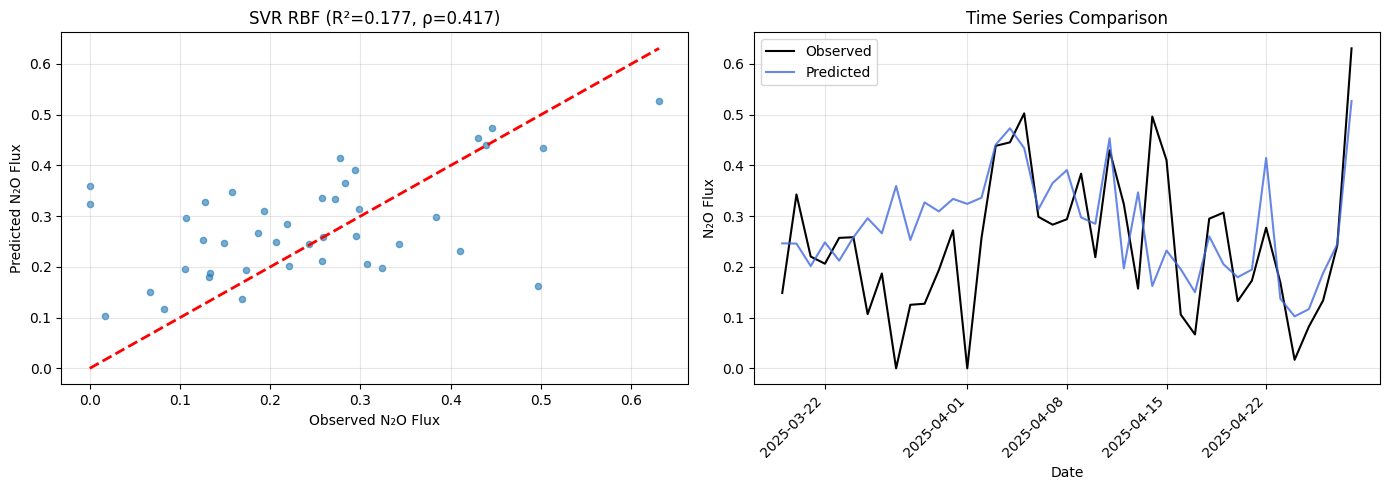


--- DAILY | target=N2O_Flux_ln | predictors=LAG ---
Train period: 2024-03-07 00:00:00 → 2025-03-05 00:00:00
Test  period: 2025-03-06 00:00:00 → 2025-05-03 00:00:00
  ✅ No data leakage detected

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): 0.521
  Spearman ρ:        0.731


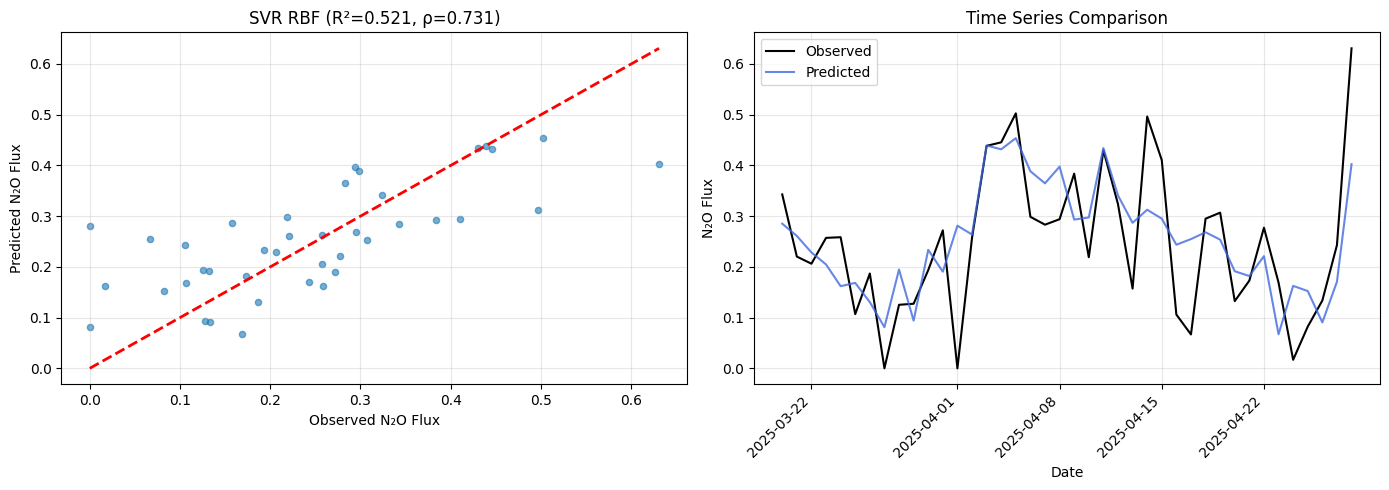


--- DAILY | target=N2O_Flux_ln | predictors=AUGMENTED ---
Train period: 2024-03-07 00:00:00 → 2025-03-05 00:00:00
Test  period: 2025-03-06 00:00:00 → 2025-05-03 00:00:00
  ✅ No data leakage detected

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): 0.446
  Spearman ρ:        0.665


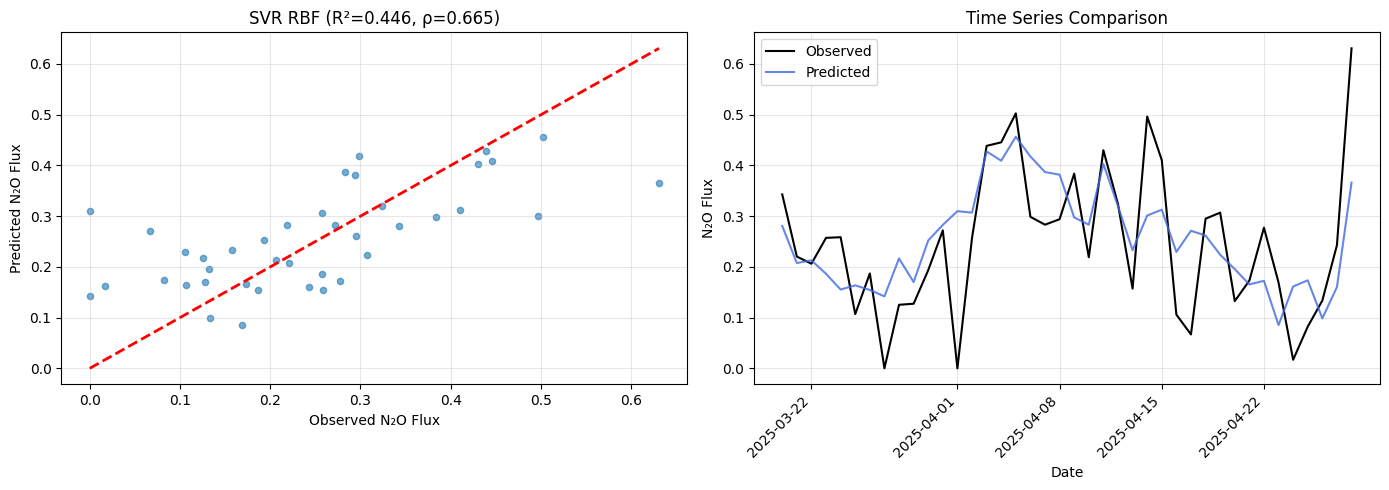


COMPREHENSIVE COMPARISON OF ALL EXPERIMENTS:
Temporal     Predictors   R²       Spearman ρ  
--------------------------------------------------------------------------------
Hourly       Base          0.111        0.428
Hourly       Lag          -0.001        0.337
Hourly       Augmented     0.156        0.395
Daily        Base          0.177        0.417
Daily        Lag           0.521        0.731
Daily        Augmented     0.446        0.665

IMPROVEMENT FROM BASE TO LAG:
Hourly: R² + -0.111, ρ + -0.092
Daily:  R² +  0.344, ρ +  0.314

IMPROVEMENT FROM LAG TO AUGMENTED:
Hourly: R² +  0.156, ρ +  0.058
Daily:  R² + -0.075, ρ + -0.066


In [33]:
# ============================================================================
# FOREL
# ============================================================================

print("="*80)
print("EXPERIMENT 5: Forel 2024-2025")
print("="*80)

# Define base and lag predictors
base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "Fertilizer_N_kg_ha"
]

lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO", 

    # --- Meteorological lag variables ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral", "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d" , "Fertilizer_N_kg_ha_expHL14d"
]

augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # Management events and days since
    "Mowing", "FertilizerOrganic", "FertilizerMineral",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral", "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d" , "Fertilizer_N_kg_ha_expHL14d"
]

# Store results for comparison
all_results = []

# ============================================================================
# HOURLY DATA - BASE PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=BASE ---")
print("="*80)

results_hourly_base = train_svr_timeseries(
    df=forel_lag,
    predictors=base_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Base", results_hourly_base['r2'], results_hourly_base['spearman_rho']))


# ============================================================================
# HOURLY DATA - LAG PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=LAG ---")
print("="*80)

results_hourly_lag = train_svr_timeseries(
    df=forel_lag,
    predictors=lag_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Lag", results_hourly_lag['r2'], results_hourly_lag['spearman_rho']))


# ============================================================================
# HOURLY DATA - AUGMENTED PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=AUGMENTED ---")
print("="*80)

results_hourly_augmented = train_svr_timeseries(
    df=forel_lag,
    predictors=augmented_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Augmented", results_hourly_augmented['r2'], results_hourly_augmented['spearman_rho']))

# ============================================================================
# DAILY DATA - BASE PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=BASE ---")
print("="*80)

results_daily_base = train_svr_timeseries(
    df=forel_daily,
    predictors=base_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Base", results_daily_base['r2'], results_daily_base['spearman_rho']))

# ============================================================================
# DAILY DATA - LAG PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=LAG ---")
print("="*80)

results_daily_lag = train_svr_timeseries(
    df=forel_daily,
    predictors=lag_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Lag", results_daily_lag['r2'], results_daily_lag['spearman_rho']))


# ============================================================================
# DAILY DATA - AUGMENTED PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=AUGMENTED ---")
print("="*80)

results_daily_augmented = train_svr_timeseries(
    df=forel_daily,
    predictors=augmented_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Augmented", results_daily_augmented['r2'], results_daily_augmented['spearman_rho']))

# ============================================================================
# COMPREHENSIVE COMPARISON
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON OF ALL EXPERIMENTS:")
print("="*80)
print(f"{'Temporal':<12} {'Predictors':<12} {'R²':<8} {'Spearman ρ':<12}")
print("-"*80)
for temp, pred, r2, rho in all_results:
    print(f"{temp:<12} {pred:<12} {r2:>6.3f}   {rho:>10.3f}")

print("\n" + "="*80)
print("IMPROVEMENT FROM BASE TO LAG:")
print("="*80)
print(f"Hourly: R² + {(results_hourly_lag['r2'] - results_hourly_base['r2']):>6.3f}, ρ + {(results_hourly_lag['spearman_rho'] - results_hourly_base['spearman_rho']):>6.3f}")
print(f"Daily:  R² + {(results_daily_lag['r2'] - results_daily_base['r2']):>6.3f}, ρ + {(results_daily_lag['spearman_rho'] - results_daily_base['spearman_rho']):>6.3f}")

print("\n" + "="*80)
print("IMPROVEMENT FROM LAG TO AUGMENTED:")
print("="*80)
print(f"Hourly: R² + {(results_hourly_augmented['r2'] - results_hourly_lag['r2']):>6.3f}, ρ + {(results_hourly_augmented['spearman_rho'] - results_hourly_lag['spearman_rho']):>6.3f}")
print(f"Daily:  R² + {(results_daily_augmented['r2'] - results_daily_lag['r2']):>6.3f}, ρ + {(results_daily_augmented['spearman_rho'] - results_daily_lag['spearman_rho']):>6.3f}")

# Experiment 6: Tanikon

In [34]:
# FIX TIMESTAMP
tanikon_lag['Timestamp'] = pd.to_datetime(tanikon_lag['Timestamp'])
tanikon_lag = tanikon_lag.set_index('Timestamp').sort_index()

tanikon_daily['Date'] = pd.to_datetime(tanikon_daily['Date'])
tanikon_daily = tanikon_daily.set_index('Date').sort_index()

EXPERIMENT 6: Tanikon 2023-2025

--- HOURLY | target=N2O_Flux_ln | predictors=BASE ---
Train period: 2023-11-07 15:45:00 → 2025-02-17 03:45:00
Test  period: 2025-02-17 04:15:00 → 2025-06-05 00:45:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -32.892
  Spearman ρ:        0.088


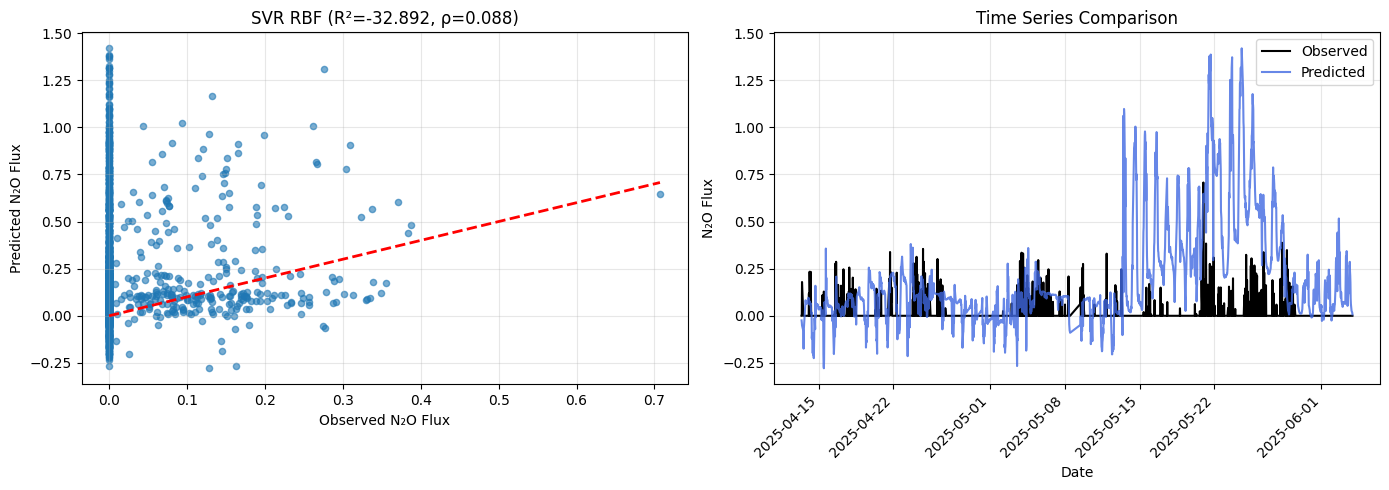


--- HOURLY | target=N2O_Flux_ln | predictors=LAG ---
Train period: 2023-11-07 15:45:00 → 2025-01-30 12:15:00
Test  period: 2025-01-30 12:45:00 → 2025-06-05 00:45:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -20.637
  Spearman ρ:        0.148


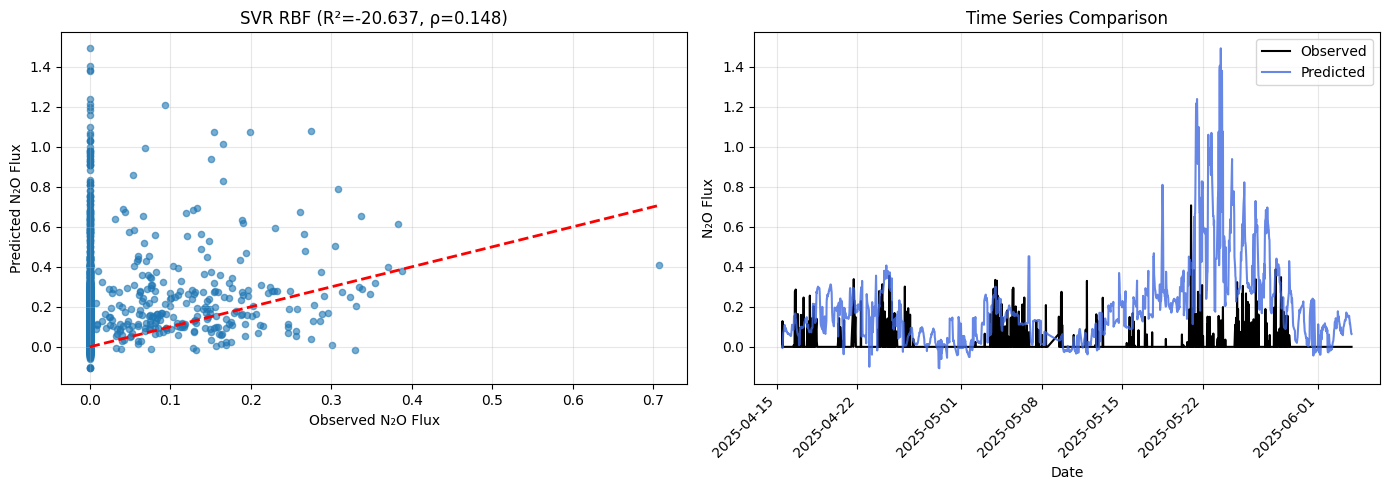


--- HOURLY | target=N2O_Flux_ln | predictors=AUGMENTED ---
Train period: 2023-11-07 15:45:00 → 2025-01-30 12:15:00
Test  period: 2025-01-30 12:45:00 → 2025-06-05 00:45:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -23.628
  Spearman ρ:        0.117


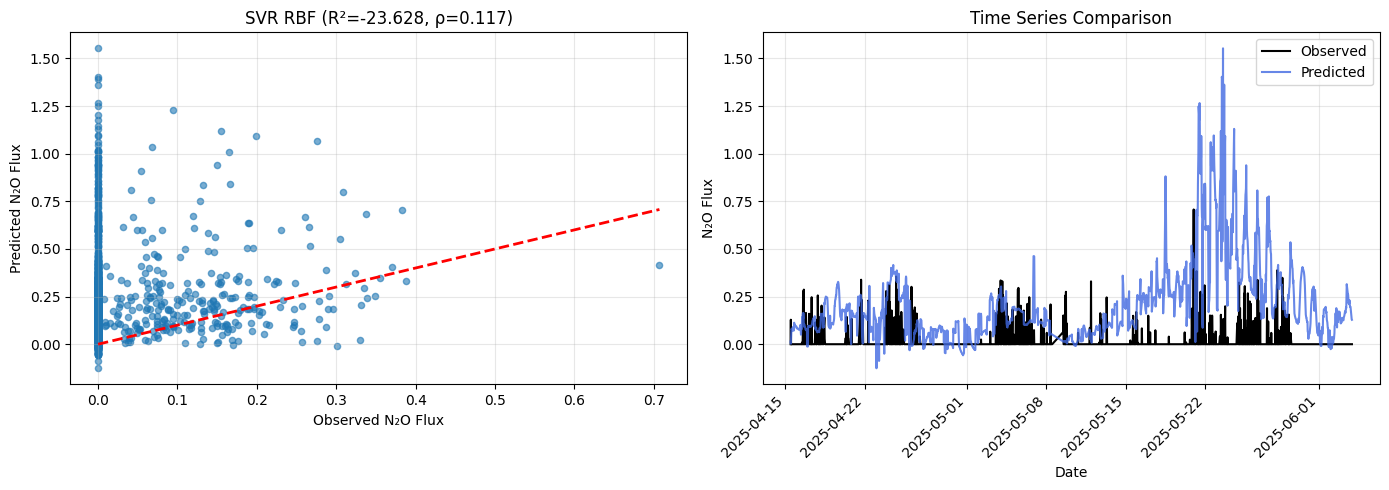


--- DAILY | target=N2O_Flux_ln | predictors=BASE ---
Train period: 2023-11-07 00:00:00 → 2025-02-16 00:00:00
Test  period: 2025-02-17 00:00:00 → 2025-06-04 00:00:00
  ✅ No data leakage detected

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -75.583
  Spearman ρ:        0.163


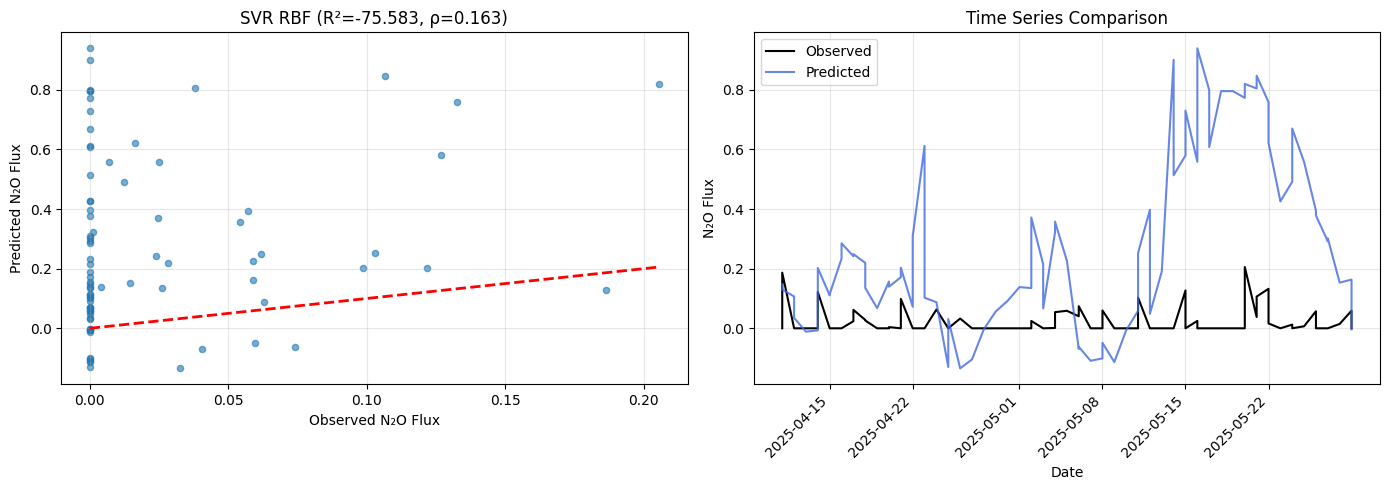


--- DAILY | target=N2O_Flux_ln | predictors=LAG ---
Train period: 2023-11-07 00:00:00 → 2025-02-03 00:00:00
Test  period: 2025-02-03 00:00:00 → 2025-06-04 00:00:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -97.215
  Spearman ρ:        0.331


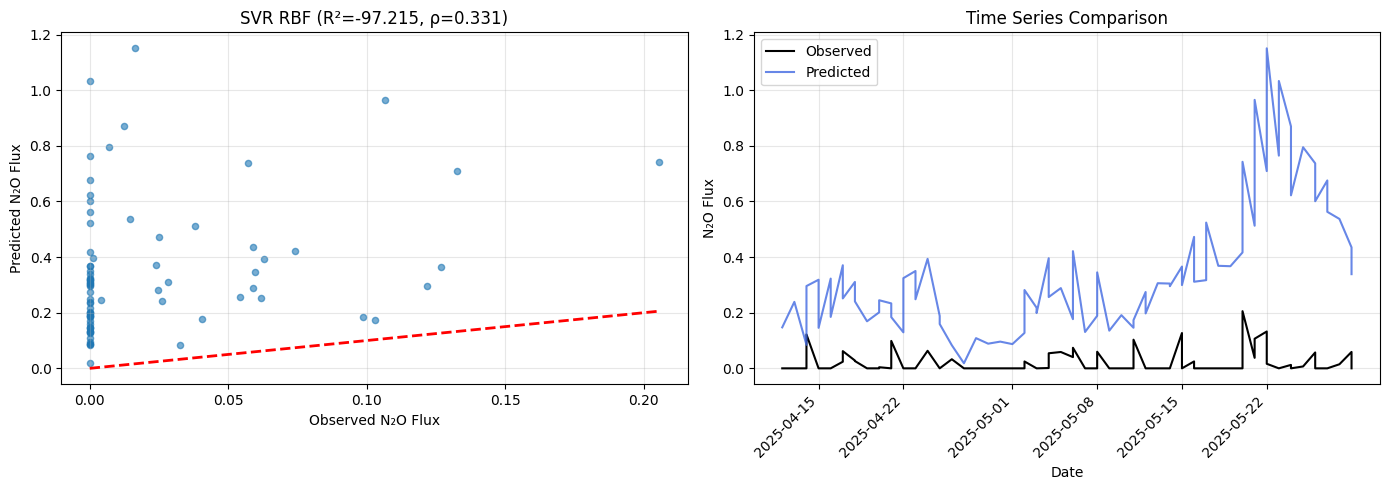


--- DAILY | target=N2O_Flux_ln | predictors=AUGMENTED ---
Train period: 2023-11-07 00:00:00 → 2025-02-03 00:00:00
Test  period: 2025-02-03 00:00:00 → 2025-06-04 00:00:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Training SVR with kernel=rbf, C=1.0, epsilon=0.1...

Model evaluation:
  R² (linear scale): -106.743
  Spearman ρ:        0.319


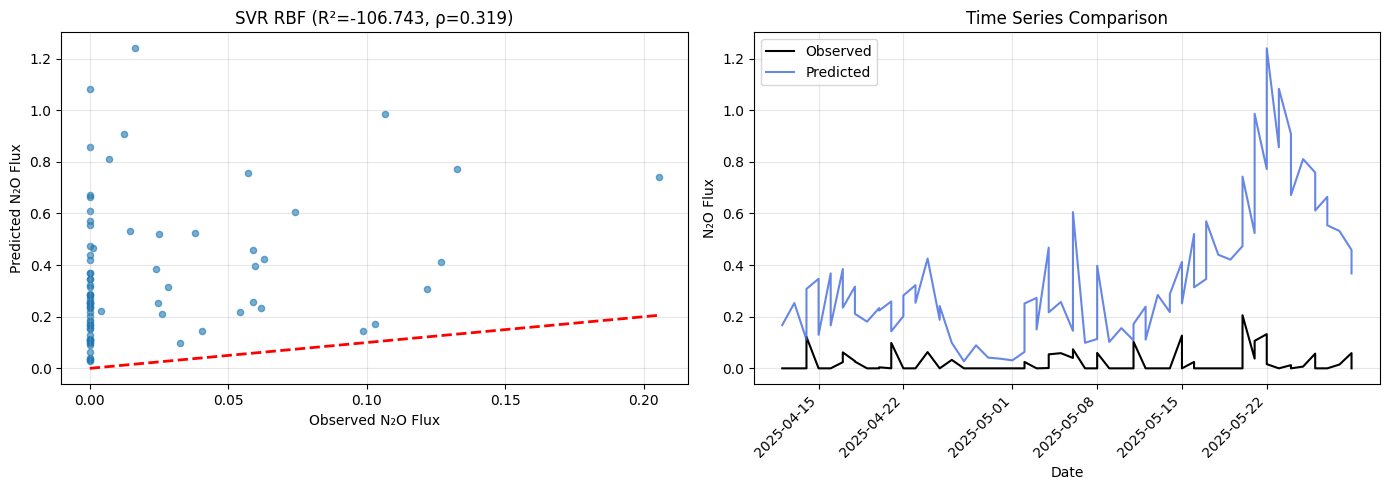


COMPREHENSIVE COMPARISON OF ALL EXPERIMENTS:
Temporal     Predictors   R²       Spearman ρ  
--------------------------------------------------------------------------------
Hourly       Base         -32.892        0.088
Hourly       Lag          -20.637        0.148
Hourly       Augmented    -23.628        0.117
Daily        Base         -75.583        0.163
Daily        Lag          -97.215        0.331
Daily        Augmented    -106.743        0.319

IMPROVEMENT FROM BASE TO LAG:
Hourly: R² + 12.255, ρ +  0.060
Daily:  R² + -21.632, ρ +  0.168

IMPROVEMENT FROM LAG TO AUGMENTED:
Hourly: R² + -2.991, ρ + -0.031
Daily:  R² + -9.528, ρ + -0.013


In [35]:
# ============================================================================
# TANIKON
# ============================================================================

print("="*80)
print("EXPERIMENT 6: Tanikon 2023-2025")
print("="*80)

# Define base and lag predictors
base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
]

hourly_lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation"
]

hourly_augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # Management events and days since
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation"
]

daily_lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation"
]

daily_augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # Management events and days since
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation"
]

# Store results for comparison
all_results = []

# ============================================================================
# HOURLY DATA - BASE PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=BASE ---")
print("="*80)

results_hourly_base = train_svr_timeseries(
    df=tanikon_lag,
    predictors=base_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Base", results_hourly_base['r2'], results_hourly_base['spearman_rho']))


# ============================================================================
# HOURLY DATA - LAG PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=LAG ---")
print("="*80)

results_hourly_lag = train_svr_timeseries(
    df=tanikon_lag,
    predictors=hourly_lag_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Lag", results_hourly_lag['r2'], results_hourly_lag['spearman_rho']))


# ============================================================================
# HOURLY DATA - AUGMENTED PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=AUGMENTED ---")
print("="*80)

results_hourly_augmented = train_svr_timeseries(
    df=tanikon_lag,
    predictors=hourly_augmented_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Augmented", results_hourly_augmented['r2'], results_hourly_augmented['spearman_rho']))

# ============================================================================
# DAILY DATA - BASE PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=BASE ---")
print("="*80)

results_daily_base = train_svr_timeseries(
    df=tanikon_daily,
    predictors=base_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Base", results_daily_base['r2'], results_daily_base['spearman_rho']))

# ============================================================================
# DAILY DATA - LAG PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=LAG ---")
print("="*80)

results_daily_lag = train_svr_timeseries(
    df=tanikon_daily,
    predictors=daily_lag_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Lag", results_daily_lag['r2'], results_daily_lag['spearman_rho']))


# ============================================================================
# DAILY DATA - AUGMENTED PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=AUGMENTED ---")
print("="*80)

results_daily_augmented = train_svr_timeseries(
    df=tanikon_daily,
    predictors=daily_augmented_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Augmented", results_daily_augmented['r2'], results_daily_augmented['spearman_rho']))

# ============================================================================
# COMPREHENSIVE COMPARISON
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON OF ALL EXPERIMENTS:")
print("="*80)
print(f"{'Temporal':<12} {'Predictors':<12} {'R²':<8} {'Spearman ρ':<12}")
print("-"*80)
for temp, pred, r2, rho in all_results:
    print(f"{temp:<12} {pred:<12} {r2:>6.3f}   {rho:>10.3f}")

print("\n" + "="*80)
print("IMPROVEMENT FROM BASE TO LAG:")
print("="*80)
print(f"Hourly: R² + {(results_hourly_lag['r2'] - results_hourly_base['r2']):>6.3f}, ρ + {(results_hourly_lag['spearman_rho'] - results_hourly_base['spearman_rho']):>6.3f}")
print(f"Daily:  R² + {(results_daily_lag['r2'] - results_daily_base['r2']):>6.3f}, ρ + {(results_daily_lag['spearman_rho'] - results_daily_base['spearman_rho']):>6.3f}")

print("\n" + "="*80)
print("IMPROVEMENT FROM LAG TO AUGMENTED:")
print("="*80)
print(f"Hourly: R² + {(results_hourly_augmented['r2'] - results_hourly_lag['r2']):>6.3f}, ρ + {(results_hourly_augmented['spearman_rho'] - results_hourly_lag['spearman_rho']):>6.3f}")
print(f"Daily:  R² + {(results_daily_augmented['r2'] - results_daily_lag['r2']):>6.3f}, ρ + {(results_daily_augmented['spearman_rho'] - results_daily_lag['spearman_rho']):>6.3f}")